**Assessment#6: Boosting Methods and Advanced Ensemble Learning**
-
* **Name:** Enrico Miguel Veloso
* **Section:** 2DSA-2
* **Course:** DSA#4155 - Artificial Intelligence
* **Date:** 3/5/2026
* **Department:** College of Science
* **Institution:** University of Santo Tomas
----
* **Implementation of models and concepts:** AdaBoost, Gradient Boosting, and Ensemble Comparison
* **Dataset:** Adult Income (Census 1994)
* **Dataset Description:** The Adult Income dataset contains demographic and employment information for 32,561 individuals from the 1994 U.S. Census. In this assessment, you will implement boosting methods (AdaBoost and Gradient Boosting) and compare them with bagging methods and traditional classifiers. Unlike bagging which reduces variance through parallel ensemble construction, boosting sequentially builds models that focus on correcting errors from previous models, primarily reducing bias while maintaining low variance.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
import statsmodels.formula.api as smf
import random
import time
import warnings
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, validation_curve
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, mean_squared_error, mean_absolute_error, r2_score)
from sklearn.inspection import permutation_importance
from scipy.spatial.distance import pdist, squareform
from scipy.stats import entropy
warnings.filterwarnings('ignore')

#Set plotting style:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

#Set seed:
random.seed(16)

**1. Data Preparation and Quick EDA**
-

In [2]:
#Load the dataset:
df = fetch_openml('adult', version = 2, as_frame = True)
df = df.frame
df.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
#Check dataframe shape:
df_shape = df.shape

In [4]:
print("Total number of rows:", df_shape[0])
print("Total number of columns:", df_shape[1])

Total number of rows: 48842
Total number of columns: 15


In [5]:
#Dataset descriptive statistics:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
#Check for null values:
num_null_col = df.isnull().sum()
num_null_row = df.isnull().any(axis=1).sum()
num_not_null_row = df.notnull().all(axis=1).sum()

In [7]:
print(num_null_col)
print("=" * 60)
print("Total number of rows that have no null value:", num_not_null_row)
print("Total number of rows that atleast 1 null value:", num_null_row)

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64
Total number of rows that have no null value: 45222
Total number of rows that atleast 1 null value: 3620


In [8]:
#Handling missing values:
df_clean = df.dropna()
num_null_col = df_clean.isnull().sum()
num_null_row = df_clean.isnull().any(axis=1).sum()
num_not_null_row = df_clean.notnull().all(axis=1).sum()
total_rows = df.shape[0]
remaining_rows = df_clean.shape[0]
data_loss_percent = ((total_rows - remaining_rows) / total_rows) * 100

In [9]:
print(num_null_col)
print("=" * 60)
print("Total number of rows that have no null value:", num_not_null_row)
print("Total number of rows that atleast 1 null value:", num_null_row)
print("Data loss after dropping all rows with null values:", f"{data_loss_percent:.2f}","%")

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
class             0
dtype: int64
Total number of rows that have no null value: 45222
Total number of rows that atleast 1 null value: 0
Data loss after dropping all rows with null values: 7.41 %


In [10]:
#Create target variable:
df_clean['high_income'] = (df_clean['class'] == '>50K').astype(int)
df_clean = df_clean.drop('class', axis = 1)
df_clean.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,high_income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0


In [11]:
#Target variable distribution in counts and percentages:
counts = df_clean['high_income'].value_counts().sort_index()
percentages = df_clean['high_income'].value_counts(normalize=True).sort_index() * 100

In [12]:
print("=" * 40)
print("Counts:", counts)
print("=" * 40)
print("Percentages:", percentages)

Counts: high_income
0    34014
1    11208
Name: count, dtype: int64
Percentages: high_income
0    75.215603
1    24.784397
Name: proportion, dtype: float64


In [13]:
#Group all columns that are categorical:
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_cols = " | ".join(categorical_cols)

In [14]:
print("Categorical columns:", categorical_cols)

Categorical columns: workclass | education | marital-status | occupation | relationship | race | sex | native-country


In [15]:
#Convert categorical to dummy variables:
dum_WC = pd.get_dummies(df_clean['workclass'], prefix = "WC", drop_first = True).astype(int)
dum_EDUC = pd.get_dummies(df_clean['education'], prefix = "EDUC", drop_first = True).astype(int)
dum_MS = pd.get_dummies(df_clean['marital-status'], prefix = "MS", drop_first = True).astype(int)
dum_OCC = pd.get_dummies(df_clean['occupation'], prefix = "OCC", drop_first = True).astype(int)
dum_REL = pd.get_dummies(df_clean['relationship'], prefix = "REL", drop_first = True).astype(int)
dum_RCE = pd.get_dummies(df_clean['race'], prefix = "RCE", drop_first = True).astype(int)
dum_SX = pd.get_dummies(df_clean['sex'], prefix = "SX", drop_first = True).astype(int)
dum_NC = pd.get_dummies(df_clean['native-country'], prefix = "NC", drop_first = True).astype(int)
df_clean = pd.concat([df_clean, dum_WC, dum_EDUC, dum_MS, dum_OCC, dum_REL, dum_RCE, dum_SX, dum_NC], axis = 1)
df_clean = df_clean.dropna()
df_clean.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,...,NC_Portugal,NC_Puerto-Rico,NC_Scotland,NC_South,NC_Taiwan,NC_Thailand,NC_Trinadad&Tobago,NC_United-States,NC_Vietnam,NC_Yugoslavia
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,...,0,0,0,0,0,0,0,1,0,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,...,0,0,0,0,0,0,0,1,0,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,...,0,0,0,0,0,0,0,1,0,0
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,...,0,0,0,0,0,0,0,1,0,0
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,...,0,0,0,0,0,0,0,1,0,0


In [16]:
#Check if there are null values after creation of dummy variables:
print("Check if there are null values after creation of dummy variables")
print("=" * 64)
print(df_clean.isnull().sum())

Check if there are null values after creation of dummy variables
age                   0
workclass             0
fnlwgt                0
education             0
education-num         0
                     ..
NC_Thailand           0
NC_Trinadad&Tobago    0
NC_United-States      0
NC_Vietnam            0
NC_Yugoslavia         0
Length: 106, dtype: int64


In [17]:
#Drop non-numerical features or columns:
df_clean = df_clean.select_dtypes(include = ['number'])
numerical_cols = " | ".join(df_clean.columns.tolist())
num_cols = len(df_clean.columns.tolist())

In [18]:
print("Total number of columns or features:", num_cols)
print("=" * 60)
print(numerical_cols)

Total number of columns or features: 98
age | fnlwgt | education-num | capital-gain | capital-loss | hours-per-week | high_income | WC_Local-gov | WC_Never-worked | WC_Private | WC_Self-emp-inc | WC_Self-emp-not-inc | WC_State-gov | WC_Without-pay | EDUC_11th | EDUC_12th | EDUC_1st-4th | EDUC_5th-6th | EDUC_7th-8th | EDUC_9th | EDUC_Assoc-acdm | EDUC_Assoc-voc | EDUC_Bachelors | EDUC_Doctorate | EDUC_HS-grad | EDUC_Masters | EDUC_Preschool | EDUC_Prof-school | EDUC_Some-college | MS_Married-AF-spouse | MS_Married-civ-spouse | MS_Married-spouse-absent | MS_Never-married | MS_Separated | MS_Widowed | OCC_Armed-Forces | OCC_Craft-repair | OCC_Exec-managerial | OCC_Farming-fishing | OCC_Handlers-cleaners | OCC_Machine-op-inspct | OCC_Other-service | OCC_Priv-house-serv | OCC_Prof-specialty | OCC_Protective-serv | OCC_Sales | OCC_Tech-support | OCC_Transport-moving | REL_Not-in-family | REL_Other-relative | REL_Own-child | REL_Unmarried | REL_Wife | RCE_Asian-Pac-Islander | RCE_Black | RCE_

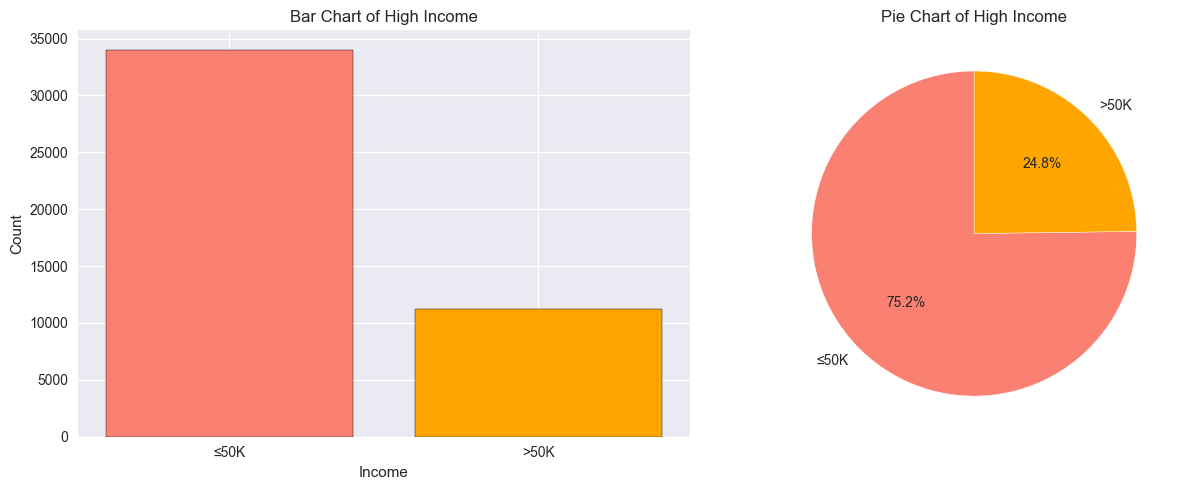

In [19]:
#Visualizations showing the distribution of the target variable:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#Bar chart (counts):
counts = df_clean['high_income'].value_counts().sort_index()
axes[0].bar(['≤50K', '>50K'], counts, color=['salmon', 'orange'], edgecolor='black')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Count')
axes[0].set_title('Bar Chart of High Income')

#Pie chart (percentages):
df_clean['high_income'].value_counts().plot.pie(autopct='%1.1f%%', labels=['≤50K', '>50K'], colors=['salmon', 'orange'], ax=axes[1], startangle=90)
axes[1].set_title('Pie Chart of High Income')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

---
* This is the distribution of values from the target variable "high_income".
* The majority of users are below or equal to the 50k marked which label's them as low incoming individuals.
* We used piechart and bar graph to better visualize the difference in number.
* There is a class imbalance in terms of individuals who have high and low income.
---

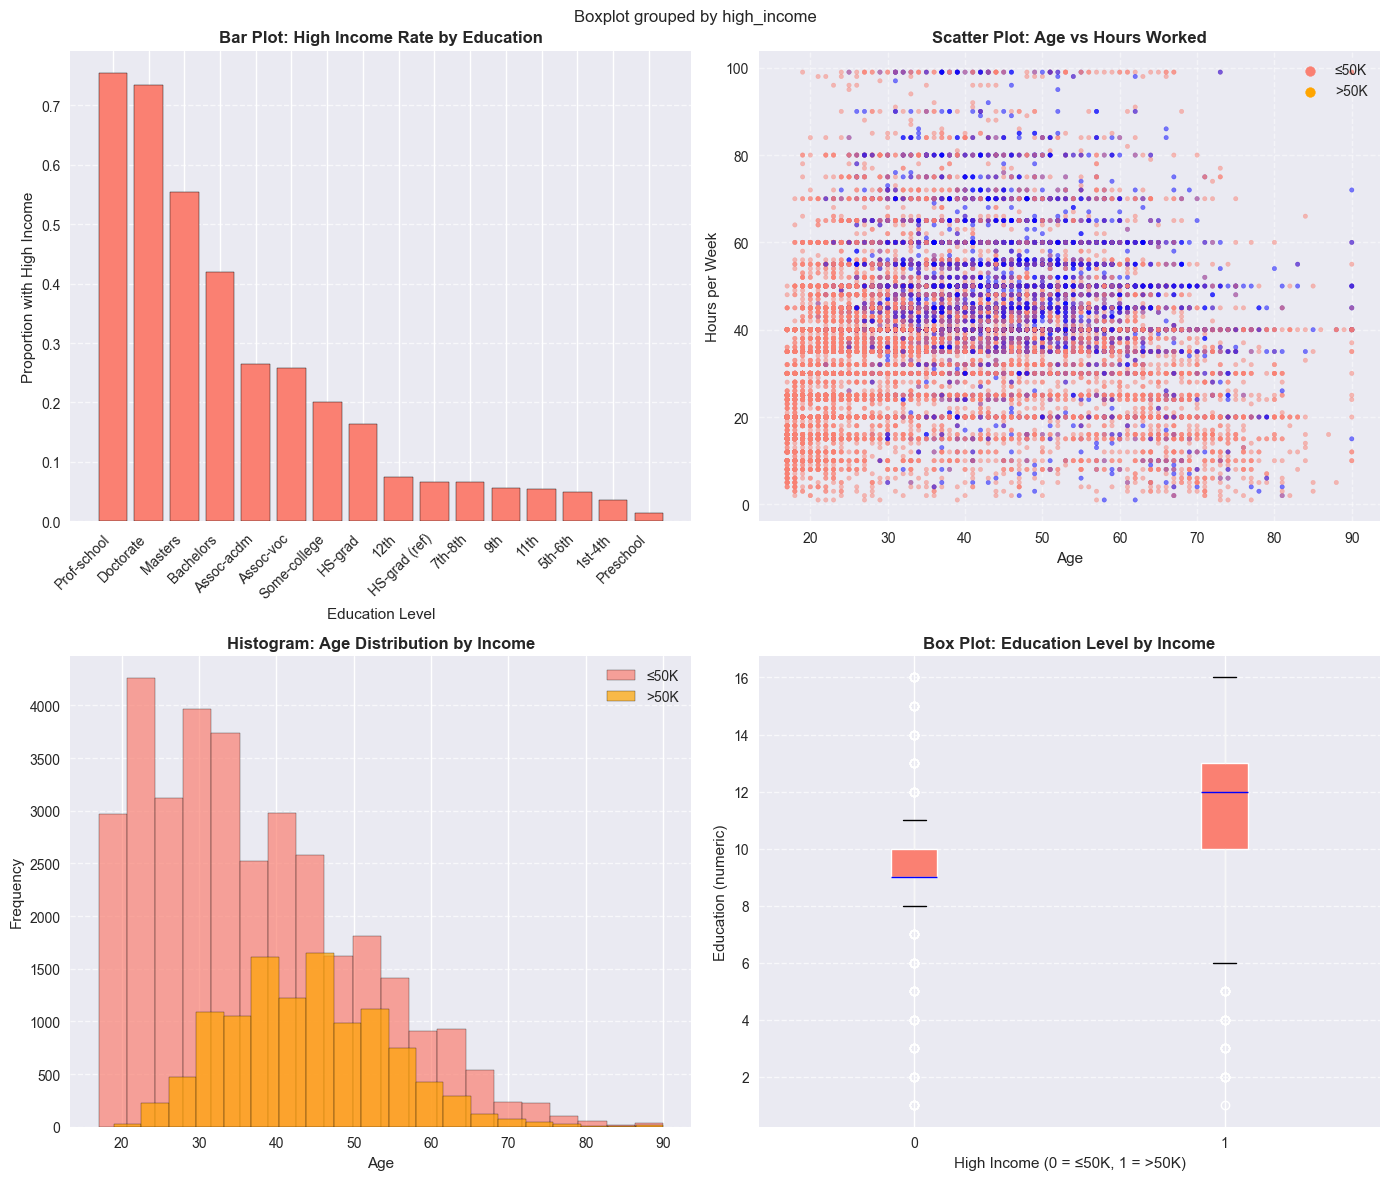

In [20]:
#Generate at least 3 informative plots exploring relationships between features and target:

#Prepare data for education bar plot (using dummy columns from your encoding):
educ_dummies = [col for col in df_clean.columns if col.startswith('EDUC_')]
educ_means = []
for col in educ_dummies:
    mean_val = df_clean.loc[df_clean[col] == 1, 'high_income'].mean()
    cat_name = col.replace('EDUC_', '')
    educ_means.append((cat_name, mean_val))

#Reference category (all dummies = 0) – label it appropriately:
ref_mask = (df_clean[educ_dummies] == 0).all(axis=1)
ref_mean = df_clean.loc[ref_mask, 'high_income'].mean()
educ_means.append(('HS-grad (ref)', ref_mean))
educ_df = pd.DataFrame(educ_means, columns=['Education', 'Proportion_High_Income'])
educ_df = educ_df.sort_values('Proportion_High_Income', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Relationships Between Features and Income', fontsize=16, fontweight='bold')

#Bar plot: Education vs High Income Rate;
ax = axes[0, 0]
bars = ax.bar(educ_df['Education'], educ_df['Proportion_High_Income'], color='salmon', edgecolor='black')
ax.set_xlabel('Education Level')
ax.set_ylabel('Proportion with High Income')
ax.set_title('Bar Plot: High Income Rate by Education', fontweight='bold')
ax.set_xticklabels(educ_df['Education'], rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

#Scatter plot: Age vs Hours per Week:
ax = axes[0, 1]
colors = df_clean['high_income'].map({0: 'salmon', 1: 'blue'})
ax.scatter(df_clean['age'], df_clean['hours-per-week'], c=colors, alpha=0.5, s=10)
ax.set_xlabel('Age')
ax.set_ylabel('Hours per Week')
ax.set_title('Scatter Plot: Age vs Hours Worked', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.scatter([], [], color='salmon', label='≤50K')
ax.scatter([], [], color='orange', label='>50K')
ax.legend()

#Histogram: Age distribution by income group:
ax = axes[1, 0]
df_clean[df_clean['high_income'] == 0]['age'].hist(ax=ax, bins=20, alpha=0.7, label='≤50K', color='salmon', edgecolor='black')
df_clean[df_clean['high_income'] == 1]['age'].hist(ax=ax, bins=20, alpha=0.7, label='>50K', color='orange', edgecolor='black')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.set_title('Histogram: Age Distribution by Income', fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

#Box plot: Education-num by income group:
ax = axes[1, 1]
df_clean.boxplot(column='education-num', by='high_income', ax=ax, patch_artist=True, boxprops=dict(facecolor='salmon'), medianprops=dict(color='blue'))
ax.set_title('Box Plot: Education Level by Income', fontweight='bold')
ax.set_xlabel('High Income (0 = ≤50K, 1 = >50K)')
ax.set_ylabel('Education (numeric)')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
* **Created 4 visualizations about the following:**
  * **Bar Plot:** which depicts high income rate by education.
  * **Scatter Plot:** depicts age vs hour worked.
  * **Histogram:** shows the distribution age by income.
  * **Box Plot:** which emphasizes education level by income.
---

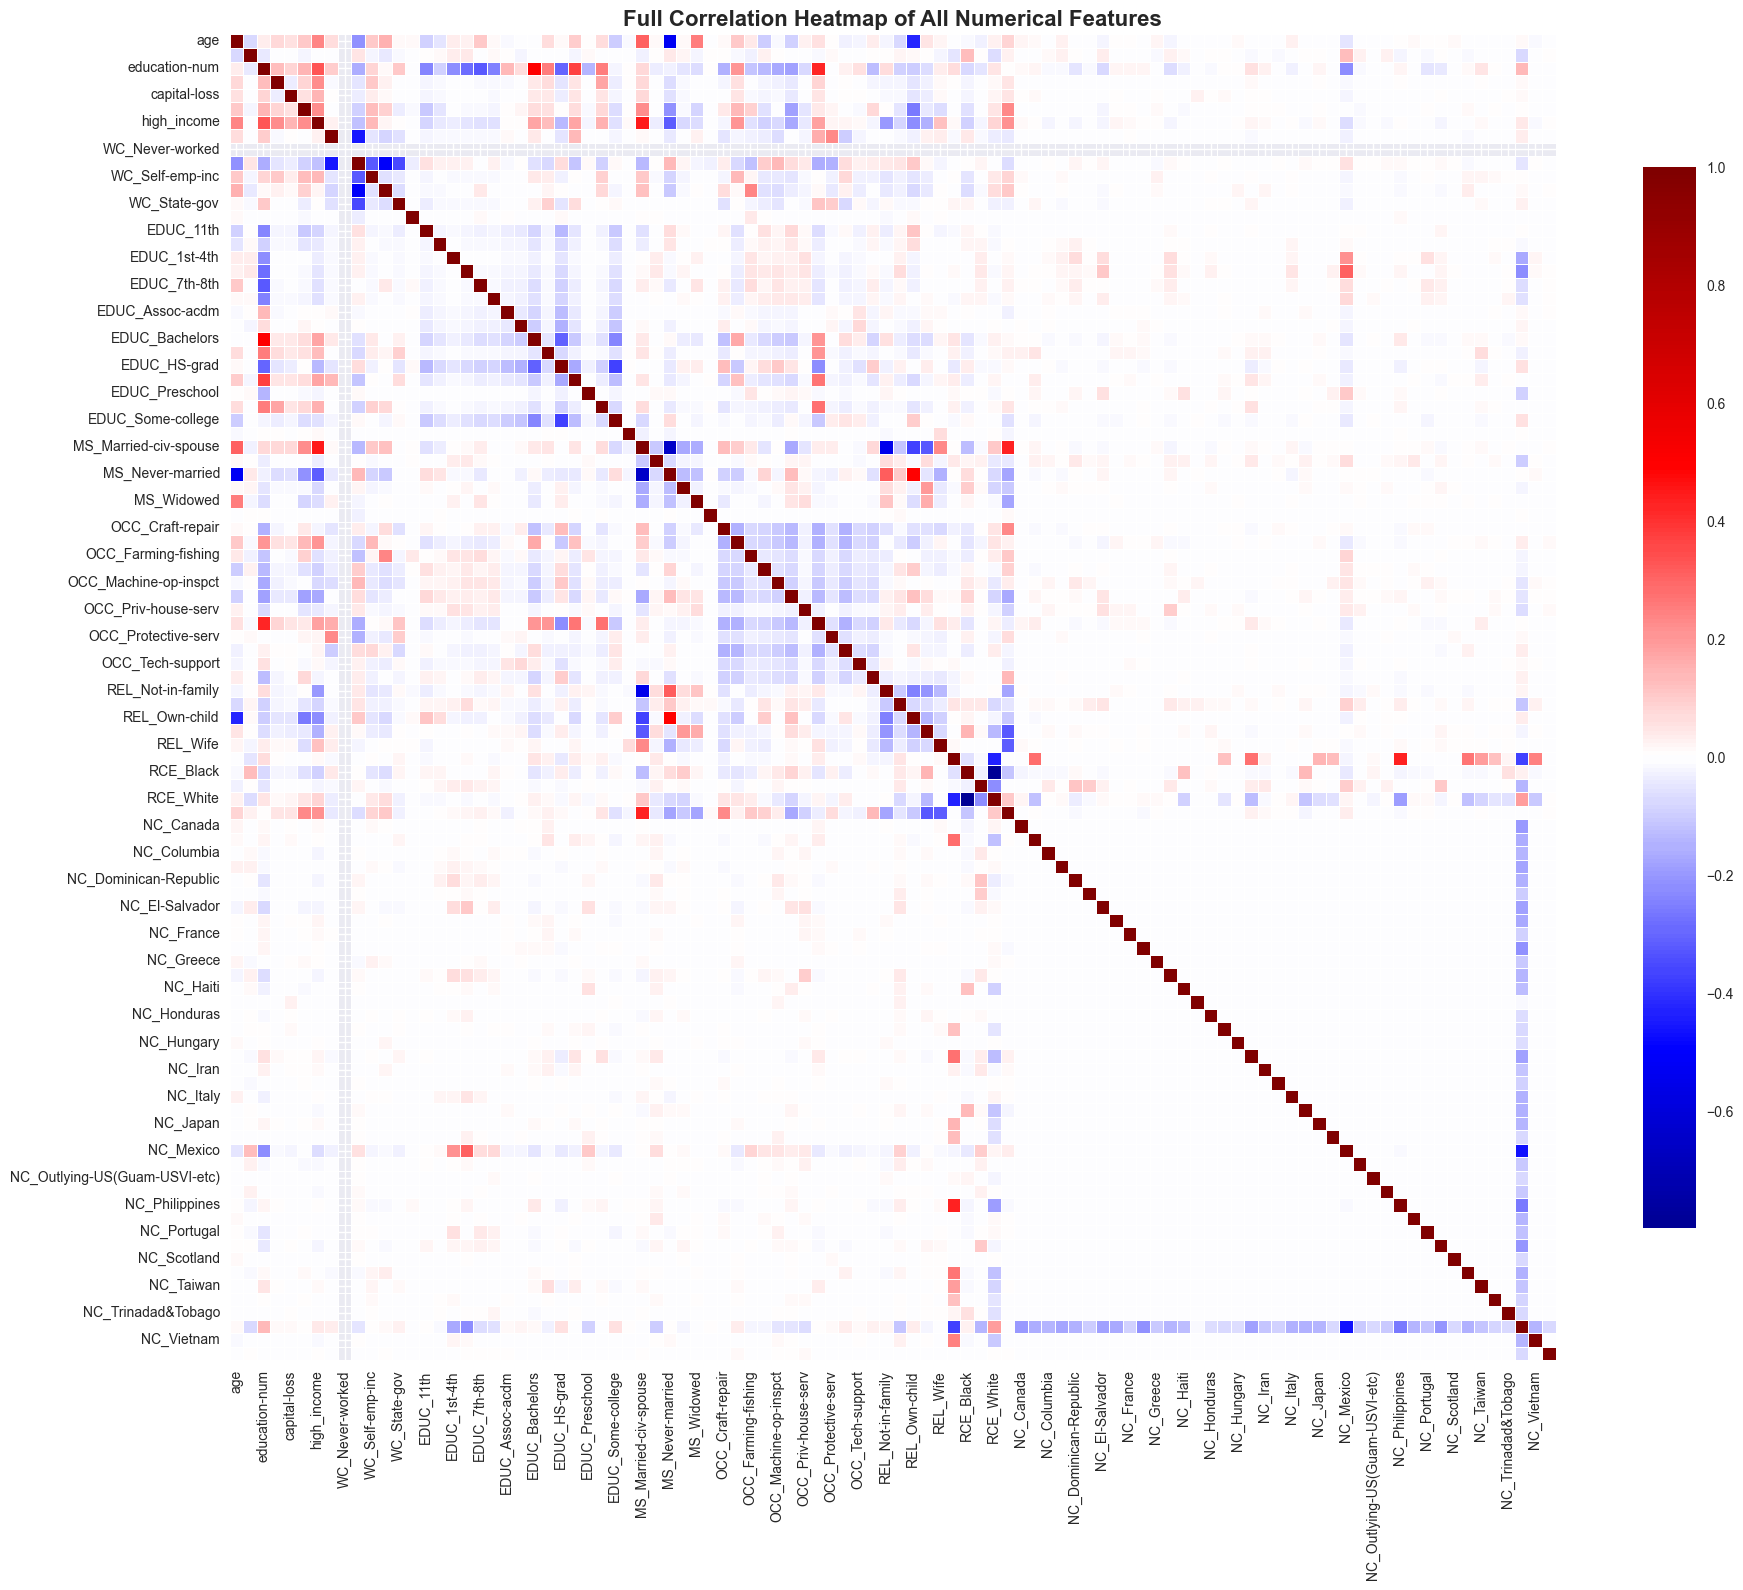

In [21]:
#Correlation heatmap for numerical features:
plt.figure(figsize=(20, 16))
corr_full = df_clean.corr()
sns.heatmap(corr_full, annot=False, cmap='seismic', center=0,square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Full Correlation Heatmap of All Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

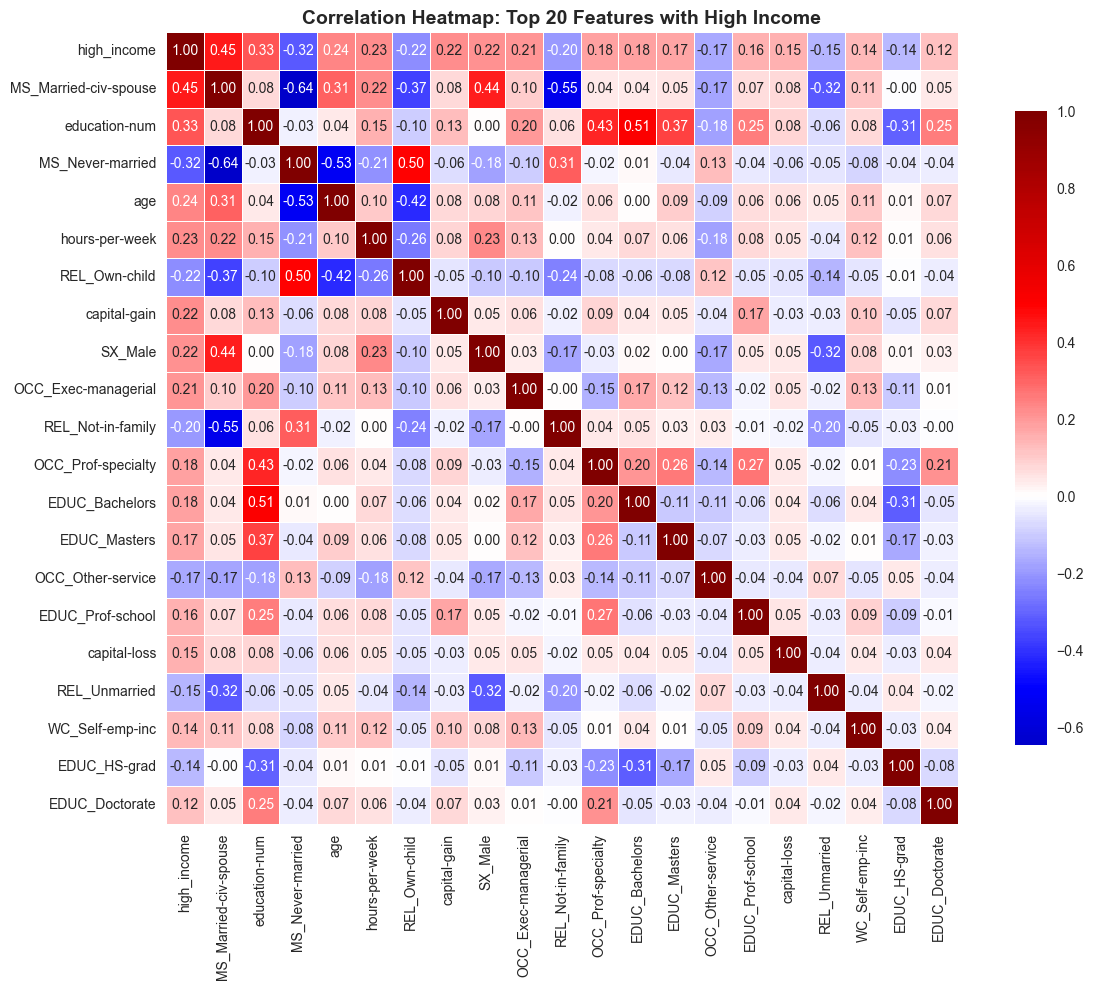

In [22]:
#Focused heatmap: top 20 features most correlated with high_income:
corr_target = df_clean.corr()['high_income'].abs().sort_values(ascending=False)
top_features = corr_target.head(21).index
plt.figure(figsize=(13, 10))
sns.heatmap(df_clean[top_features].corr(), annot=True, fmt='.2f', cmap='seismic', center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Top 20 Features with High Income', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**2. Train-Test Split and Feature Selection**
-

In [23]:
#Prepare your feature (X) and target variable (y) for Random Forest application of features selection:
X = df_clean.drop('high_income', axis = 1)
y = df_clean['high_income']

In [24]:
#Split dataframe to test and train sets for Random Forest application:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [25]:
#Display the shapes of training and testing sets:
print("Training set shape:")
print("=" * 40)
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print("=" * 40)
print("Testing set shape:")
print("=" * 40)
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Training set shape:
X_train: (36177, 97)
y_train: (36177,)
Testing set shape:
X_test: (9045, 97)
y_test: (9045,)


In [26]:
#Train a Decision Tree classifier on the training set using all features:
dt_selector = DecisionTreeClassifier(random_state = 42)
dt_selector.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [27]:
#Extract feature importance scores:
importances = dt_selector.feature_importances_
feature_names = X_train.columns

In [28]:
#Create a DataFrame for feature importance:
feat_imp_df = pd.DataFrame({'Feature': feature_names,'Importance': importances}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

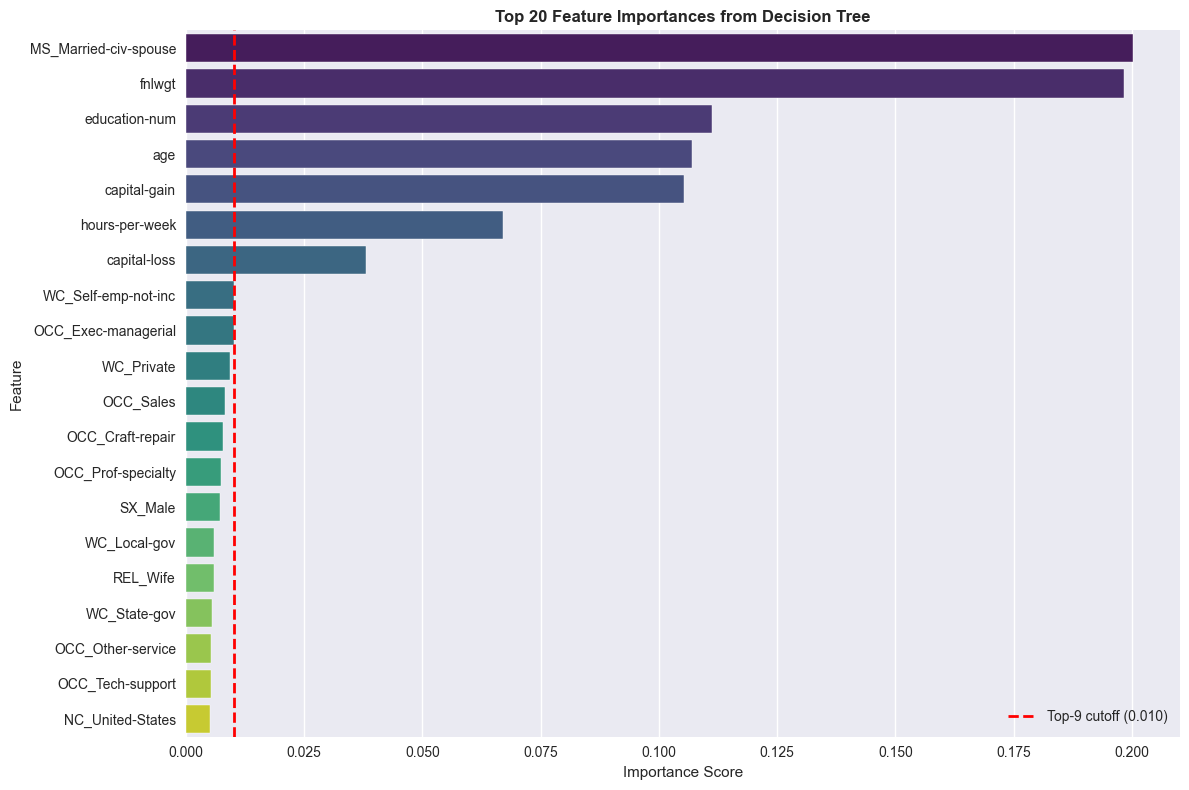

In [29]:
#Create a visualization (bar plot) showing feature importance scores:

#Show top 20 for clarity (you can adjust or show all by removing head(20)):
plt.figure(figsize=(12, 8))
top_n = 20
top_features = feat_imp_df.head(top_n)
sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')
k = 9
if len(top_features) >= k:
    threshold_value = top_features.iloc[k-1]['Importance']
    plt.axvline(x=threshold_value, color='red', linestyle='--', linewidth=2,
                label=f'Top-{k} cutoff ({threshold_value:.3f})')
    plt.legend()
plt.title(f'Top {top_n} Feature Importances from Decision Tree', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [30]:
#Select the top 12 most important features:
top_12_features = feat_imp_df.head(12)['Feature'].tolist()

In [31]:
print("Top 12 selected features:")
print("=" * 60)
print(" | ".join(top_12_features))

Top 12 selected features:
MS_Married-civ-spouse | fnlwgt | education-num | age | capital-gain | hours-per-week | capital-loss | WC_Self-emp-not-inc | OCC_Exec-managerial | WC_Private | OCC_Sales | OCC_Craft-repair


In [32]:
#Create a table showing: Feature name, Importance score, Selected (Yes/No):
feat_imp_df['Selected'] = feat_imp_df['Feature'].isin(top_12_features).map({True: 'Yes', False: 'No'})

In [33]:
print("Top 12 features with selection status:")
print("=" * 55)
print(feat_imp_df.head(12).to_string(index=False))

Top 12 features with selection status:
              Feature  Importance Selected
MS_Married-civ-spouse    0.200170      Yes
               fnlwgt    0.198372      Yes
        education-num    0.111147      Yes
                  age    0.107072      Yes
         capital-gain    0.105384      Yes
       hours-per-week    0.067045      Yes
         capital-loss    0.038142      Yes
  WC_Self-emp-not-inc    0.010269      Yes
  OCC_Exec-managerial    0.010255      Yes
           WC_Private    0.009309      Yes
            OCC_Sales    0.008194      Yes
     OCC_Craft-repair    0.007870      Yes


In [34]:
#Prepare the reduced feature set (X_train_selected, X_test_selected) for model training:
X_train_selected = X_train[top_12_features]
X_test_selected = X_test[top_12_features]

In [35]:
print(f"Reduced feature set shape:")
print("=" * 40)
print(f"X_train_selected: {X_train_selected.shape}")
print(f"X_test_selected: {X_test_selected.shape}")

Reduced feature set shape:
X_train_selected: (36177, 12)
X_test_selected: (9045, 12)


---
**Brief Interpretation: Why use Decision Tree for feature selection before training ensemble methods?**
* **Speeds up Training:**
  * A single tree is fast, it quicklly filters out irrlevant features.
  * Reduces the dataset's dimensionality.
* **Reduces Noise and Overfitting:**
  * Removee features that are just noise which can confuse the ensemble.
  * Helps the ensemble focus on the most relevant signals, improving generalization.
* **Leverages Built-in Feature Ranking:**
  * Decision trees naturally rank features by how much they reduce impurity.
  * Provides a simple, interpretable socre for each feature without complex math.
* **Enhances Interpretability:**
  * The importance scores from a single tree are more transparent than the averaged scores from an ensemble.
  * Useful for explaining to stakeholders why certain features were kept.
* **Handles Redundancy:**
  * Among a group of correlated features, the tree will typically select the most informative one for the split, naturally reducing redundancy.
---

**3. Six-Model Training and Implementation**
-

In [36]:
#Add constant to feature set:
X_train_sm = sm.add_constant(X_train_selected)
X_test_sm = sm.add_constant(X_test_selected)

**1.) Logistic Regression:**

In [37]:
#LRM based from the selected features derived from the Decision Tree feature selection:
lrm = sm.Logit(y_train, X_train_sm).fit(maxiter = 1000)

Optimization terminated successfully.
         Current function value: 0.337472
         Iterations 8


In [38]:
#Display all coefficients with feature names in a table:
logit_coef = lrm.params[1:]
coef_logit = pd.DataFrame({'Feature': X_train_selected.columns, 'Logistic β': logit_coef.values})

In [39]:
print("Logistic Regression Coefficients:")
print("=" * 60)
print(coef_logit.to_string(index=False))

Logistic Regression Coefficients:
              Feature    Logistic β
MS_Married-civ-spouse  2.483270e+00
               fnlwgt  7.857064e-07
        education-num  3.486649e-01
                  age  2.862847e-02
         capital-gain  3.120151e-04
       hours-per-week  2.947528e-02
         capital-loss  6.645934e-04
  WC_Self-emp-not-inc -7.017862e-01
  OCC_Exec-managerial  7.631232e-01
           WC_Private -9.889366e-02
            OCC_Sales  2.614324e-01
     OCC_Craft-repair  1.658656e-01


In [40]:
#Training accuracy of Logistic Regression:
y_train_pred_prob_lrm = lrm.predict(X_train_sm)
y_train_pred_lrm = (y_train_pred_prob_lrm > 0.5).astype(int)
lrm_train_acc = accuracy_score(y_train, y_train_pred_lrm)

In [41]:
print("=" * 60)
print(f"Logistic Regression Training Accuracy: {lrm_train_acc:.4f}")

Logistic Regression Training Accuracy: 0.8438


**2.) Linear Probability Model (LPM):**

In [42]:
#LPM based from the selected features derived from the Decision Tree feature selection:
lpm = sm.OLS(y_train, X_train_sm).fit()

In [43]:
#Display all coefficients with feature names in a table:
lpm_coef = lpm.params[1:]
coef_lpm = pd.DataFrame({'Feature': X_train_selected.columns, 'LPM β': lpm_coef.values})

In [44]:
print("Linear Probability Model Coefficients:")
print("=" * 60)
print(coef_lpm.to_string(index=False))

Linear Probability Model Coefficients:
              Feature         LPM β
MS_Married-civ-spouse  3.135936e-01
               fnlwgt  9.978167e-08
        education-num  4.104225e-02
                  age  2.906474e-03
         capital-gain  8.412307e-06
       hours-per-week  2.753845e-03
         capital-loss  9.626178e-05
  WC_Self-emp-not-inc -9.278784e-02
  OCC_Exec-managerial  1.241868e-01
           WC_Private -1.777416e-02
            OCC_Sales  4.149558e-02
     OCC_Craft-repair -4.811490e-03


In [45]:
#Training accuracy of Linear Probability Model:
y_train_pred_prob_lpm = lpm.predict(X_train_sm)
y_train_pred_lpm = (y_train_pred_prob_lpm > 0.5).astype(int)
lpm_train_acc = accuracy_score(y_train, y_train_pred_lpm)

In [46]:
print("=" * 60)
print(f"Linear Probability Model Training Accuracy: {lpm_train_acc:.4f}")

Linear Probability Model Training Accuracy: 0.8342


**3.) Single Decision Tree:**

In [47]:
#Single Decision Tree - using sklearn (default parameters):
dt2 = DecisionTreeClassifier(max_depth = 5, random_state = 42)
dt2.fit(X_train_selected, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [48]:
#Training accuracy of a Single Decision Tree and node count: 
dt2_train_acc = dt2.score(X_train_selected, y_train)
dt2_nodes = dt2.tree_.node_count

In [49]:
print("=" * 60)
print(f"Single Decision Tree Training Accuracy: {dt2_train_acc:.4f}")

Single Decision Tree Training Accuracy: 0.8468


In [50]:
#Extract feature importance scores from Single Decision Tree:
importances_dt2 = dt2.feature_importances_
feature_names_dt2 = X_train_selected.columns

In [51]:
#Create a DataFrame for feature importance from Single Decision Tree:
feat_imp_df_dt2 = pd.DataFrame({'Feature': feature_names_dt2,'Importance': importances_dt2}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

In [52]:
print("Top 12 features from Single Decision Tree:")
print("=" * 45)
print(feat_imp_df_dt2.head(12).to_string(index=False))

Top 12 features from Single Decision Tree:
              Feature  Importance
MS_Married-civ-spouse    0.472640
        education-num    0.236220
         capital-gain    0.216369
         capital-loss    0.052318
       hours-per-week    0.011608
                  age    0.010836
  WC_Self-emp-not-inc    0.000009
               fnlwgt    0.000000
  OCC_Exec-managerial    0.000000
           WC_Private    0.000000
            OCC_Sales    0.000000
     OCC_Craft-repair    0.000000


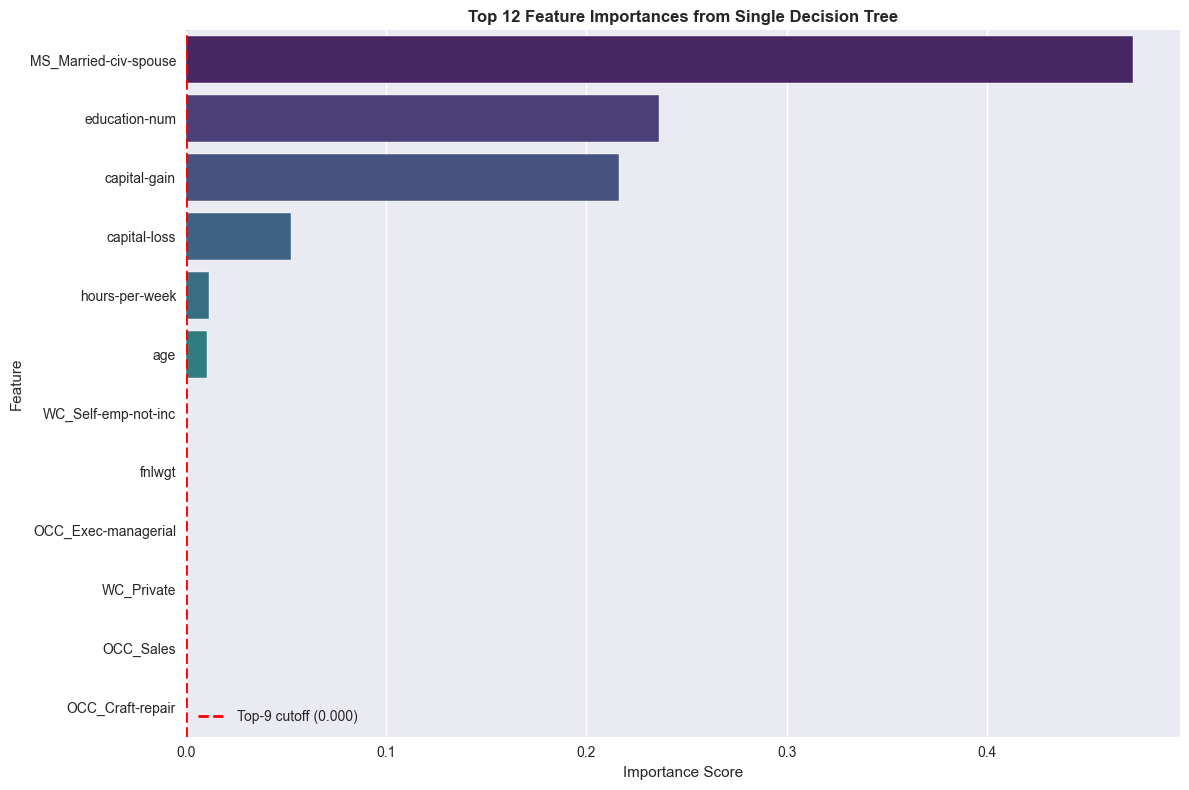

In [53]:
#Create a visualization (bar plot) showing feature importance scores from Single Decision Tree:

#Show all 12 for clarity (you can adjust or show all by removing head(12)):
plt.figure(figsize=(12, 8))
top_n = 12
top_features = feat_imp_df_dt2.head(top_n)
sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')
k = 9
if len(top_features) >= k:
    threshold_value = top_features.iloc[k-1]['Importance']
    plt.axvline(x=threshold_value, color='red', linestyle='--', linewidth=2,
                label=f'Top-{k} cutoff ({threshold_value:.3f})')
    plt.legend()
plt.title(f'Top {top_n} Feature Importances from Single Decision Tree', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**4.) Random Forest:**

In [54]:
#Random Forest - using sklearn:
rf = RandomForestClassifier(n_estimators = 100, random_state = 42, max_depth = 5)
rf.fit(X_train_selected, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [55]:
#Random Forest training accuracy:
rf_train_acc = rf.score(X_train_selected, y_train)

In [56]:
print("=" * 60)
print(f"Random Forest Training Accuracy: {rf_train_acc:.4f}")

Random Forest Training Accuracy: 0.8492


In [57]:
#Extract feature importance scores from Random Forest (selected 12 features):
importances_rf = rf.feature_importances_
feature_names_rf = X_train_selected.columns

In [58]:
#Create a DataFrame for feature importance from Random Forest (selected 12 features):
feat_imp_df_rf = pd.DataFrame({'Feature': feature_names_rf,'Importance': importances_rf}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

In [59]:
print("Top 12 features from Random Forest (selected 12 features):")
print("=" * 60)
print(feat_imp_df_rf.head(12).to_string(index=False))

Top 12 features from Random Forest (selected 12 features):
              Feature  Importance
MS_Married-civ-spouse    0.345845
         capital-gain    0.237833
        education-num    0.173292
                  age    0.087889
       hours-per-week    0.058149
         capital-loss    0.045267
  OCC_Exec-managerial    0.041283
           WC_Private    0.003876
  WC_Self-emp-not-inc    0.002596
     OCC_Craft-repair    0.001728
               fnlwgt    0.001691
            OCC_Sales    0.000552


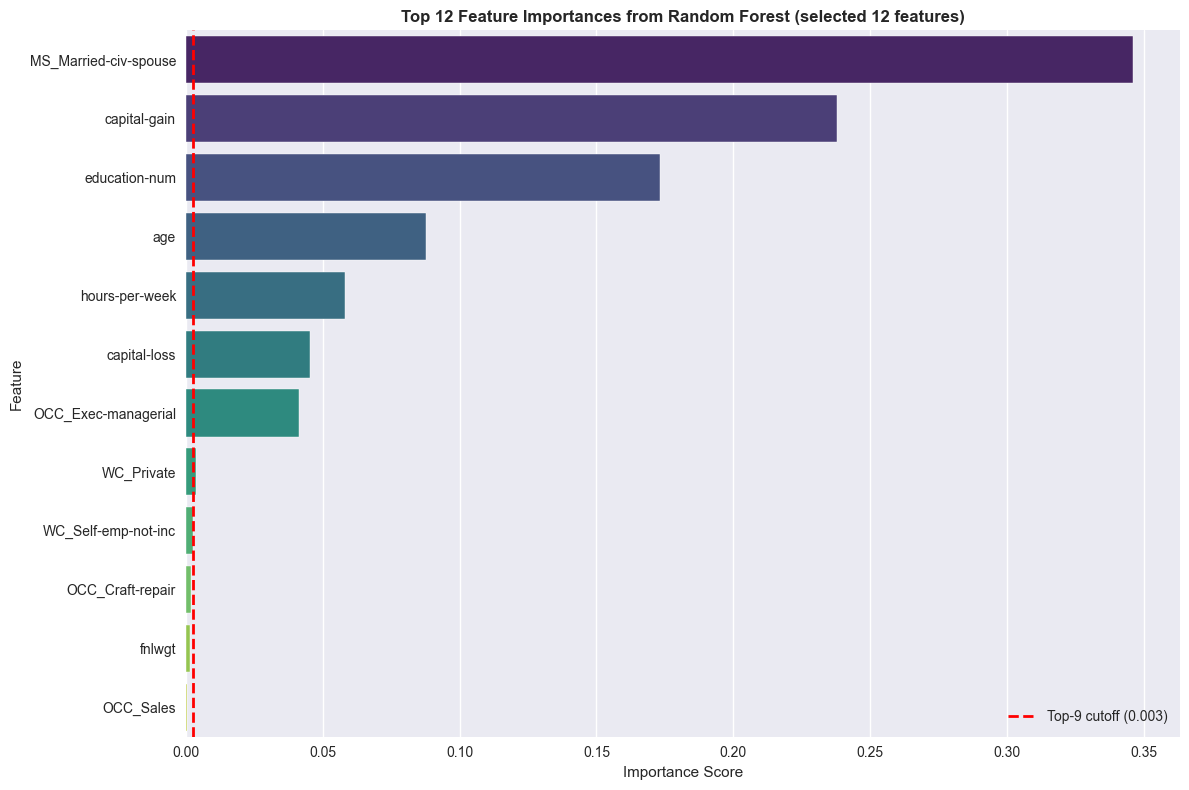

In [60]:
#Create a visualization (bar plot) showing feature importance scores from Random Forest (selected 12 features):

#Show all 12 for clarity (you can adjust or show all by removing head(12)):
plt.figure(figsize=(12, 8))
top_n = 12
top_features = feat_imp_df_rf.head(top_n)
sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')
k = 9
if len(top_features) >= k:
    threshold_value = top_features.iloc[k-1]['Importance']
    plt.axvline(x=threshold_value, color='red', linestyle='--', linewidth=2,
                label=f'Top-{k} cutoff ({threshold_value:.3f})')
    plt.legend()
plt.title(f'Top {top_n} Feature Importances from Random Forest (selected 12 features)', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

---
**Brief explanation: How does Random Forest reduce variance through parallel ensemble construction?**
* **Random Forest reduces variance via:**
  * **Bagging:** Each tree trained on a different random sample of data (with replacment). Creates diverse trees.
  * **Random Feature Selection:** Each splt considers random subset of features. Decorrelates trees.
  * **Averaging Predidctions:** Final ouput = average (regression) or majority vote (classification). Error Cancellation: Individua tree errors cancel out when averaged.
---

**5.) AdaBoost:**

In [61]:
#AdaBoost based from the selected features derived from the Decision Tree feature selection:
ada_bst = AdaBoostClassifier(estimator = DecisionTreeClassifier(), n_estimators = 100, random_state = 42, learning_rate = 1.0)
ada_bst.fit(X_train_selected, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [62]:
#AdaBoost Training Accuracy:
ada_train_acc = ada_bst.score(X_train_selected, y_train)

In [63]:
print("=" * 60)
print(f"AdaBoost Training Accuracy: {ada_train_acc:.4f}")

AdaBoost Training Accuracy: 0.9998


In [64]:
#Extract feature importance scores from AdaBoost (selected 12 features):
importances_ada = ada_bst.feature_importances_
feature_names_ada = X_train_selected.columns

In [65]:
#Create a DataFrame for feature importance from AdaBoost (selected 12 features):
feat_imp_df_ada = pd.DataFrame({'Feature': feature_names_ada,'Importance': importances_ada}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

In [66]:
print("Top 12 features from AdaBoost (selected 12 features):")
print("=" * 60)
print(feat_imp_df_ada.head(12).to_string(index=False))

Top 12 features from AdaBoost (selected 12 features):
              Feature  Importance
               fnlwgt    0.204352
MS_Married-civ-spouse    0.198959
        education-num    0.187045
                  age    0.177904
         capital-gain    0.073896
       hours-per-week    0.065896
         capital-loss    0.028291
           WC_Private    0.019214
  OCC_Exec-managerial    0.017265
     OCC_Craft-repair    0.010939
            OCC_Sales    0.009455
  WC_Self-emp-not-inc    0.006785


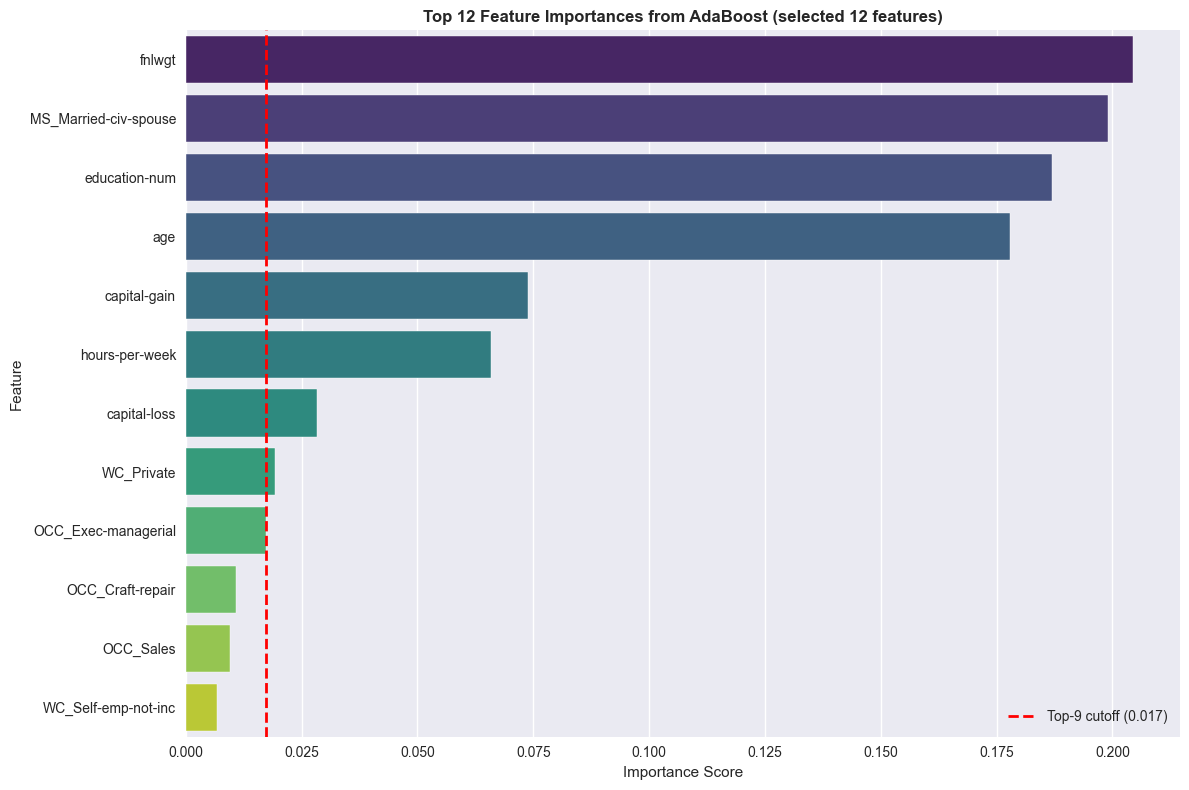

In [67]:
#Create a visualization (bar plot) showing feature importance scores from AdaBoost (selected 12 features):

#Show all 12 for clarity (you can adjust or show all by removing head(12)):
plt.figure(figsize=(12, 8))
top_n = 12
top_features = feat_imp_df_ada.head(top_n)
sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')
k = 9
if len(top_features) >= k:
    threshold_value = top_features.iloc[k-1]['Importance']
    plt.axvline(x=threshold_value, color='red', linestyle='--', linewidth=2,
                label=f'Top-{k} cutoff ({threshold_value:.3f})')
    plt.legend()
plt.title(f'Top {top_n} Feature Importances from AdaBoost (selected 12 features)', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

---
**Detailed Explanation:**
* **How does AdaBoost sequentially focus on misclassified samples?**
  * AdaBoost builds a high-performing ensemble by sequentially training weak learners to prioritize the "hardest" cases through adjusted weights, ultimately uniting them into a final, weighted consensus.
* **What is the role of sample weights in AdaBoost?**
  * AdaBoost leverages sample weights to spotlight difficult instances and calibrate each learner's influence, ultimately synthesizing them into a final prediction through a strategically weighted voting system.
* **Why use weal learners (stumps with max_depth = 1)?**
  * **Prevents overfitting:** Shallows trees have high bias but low variance. Boosting's sequential correction handles the bias, while the simplicity keeps variance in check.
  * **Forces sequential learning:** Each stump can only fix a smiall portion of errors. This forces the algorithm to make iterations, gradually improving where previous models failed.
  * **Computational efficiency:** Stumps are extremely fast to train.. Since boosting is sequential, using simple learners keeps training time manageable.
  * **Complementary to boosting's strength:** Boosting excels at combining many weak models into one strong model. Complex learners would compete with this process rather than compliment it.
* **How does the "learning_rate=" parameter affect the algorithm?**
  * The learning rate acts as a regularizer by scaling each weak learner's contribution, creating a strategic trade-off where smaller, more cautious steps reduce overfitting but require a higher number of estimators to reach the optimal solution.
---

**6.) Gradient Boost**

In [68]:
#Gradient Boost based from the selected features derived from the Decision Tree feature selection:
grad_bst = GradientBoostingClassifier(n_estimators = 100, random_state = 42, learning_rate = 0.1, max_depth = 3)
grad_bst.fit(X_train_selected, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [69]:
#Gradient Boost Training Accuracy:
grad_train_acc = grad_bst.score(X_train_selected, y_train)

In [70]:
print("=" * 60)
print(f"Gradient Boost Training Accuracy: {grad_train_acc:.4f}")

Gradient Boost Training Accuracy: 0.8626


In [71]:
#Extract feature importance scores from Gradient Boost (selected 12 features):
importances_grad = grad_bst.feature_importances_
feature_names_grad = X_train_selected.columns

In [72]:
#Create a DataFrame for feature importance from Gradient Boost (selected 12 features):
feat_imp_df_grad = pd.DataFrame({'Feature': feature_names_grad,'Importance': importances_grad}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

In [73]:
print("Top 12 features from Gradietn Boost (selected 12 features):")
print("=" * 60)
print(feat_imp_df_grad.head(12).to_string(index=False))

Top 12 features from Gradietn Boost (selected 12 features):
              Feature  Importance
MS_Married-civ-spouse    0.398626
        education-num    0.215149
         capital-gain    0.206514
         capital-loss    0.058490
                  age    0.056787
       hours-per-week    0.034465
  OCC_Exec-managerial    0.018361
  WC_Self-emp-not-inc    0.007347
               fnlwgt    0.003131
            OCC_Sales    0.000967
           WC_Private    0.000117
     OCC_Craft-repair    0.000047


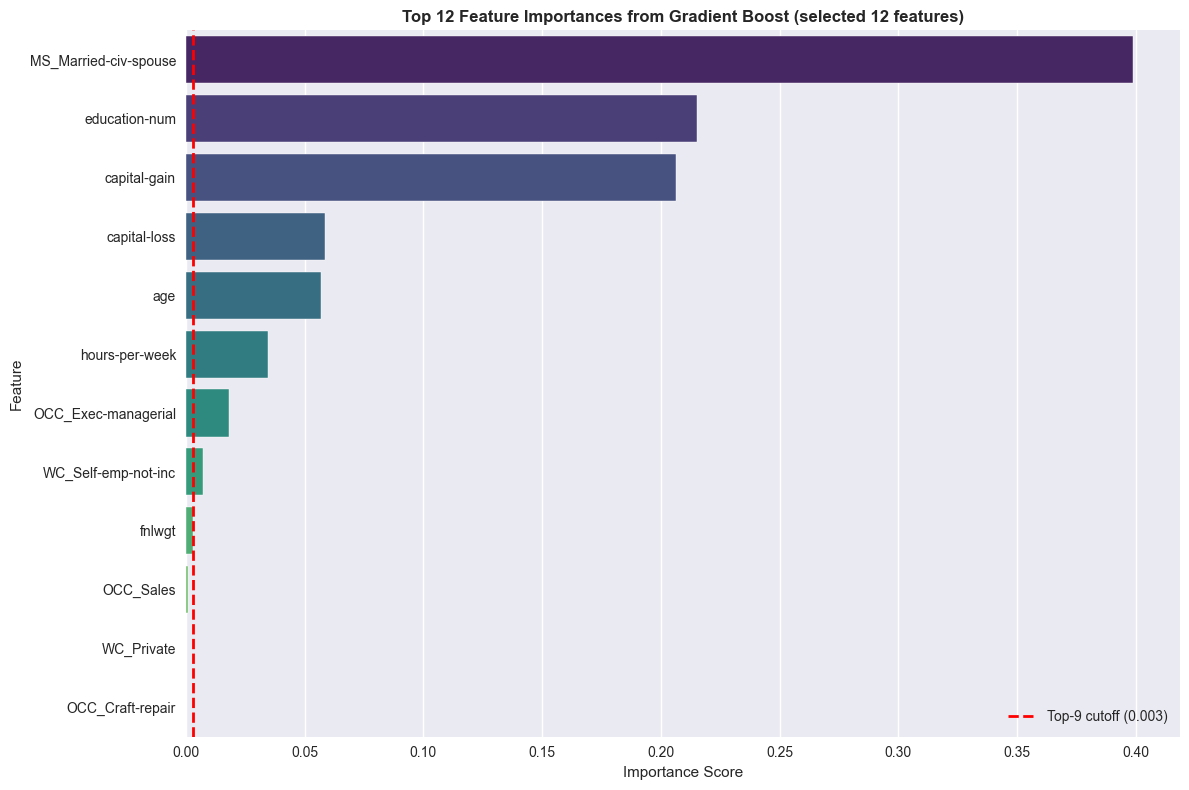

In [74]:
#Create a visualization (bar plot) showing feature importance scores from Gradient Boost (selected 12 features):

#Show all 12 for clarity (you can adjust or show all by removing head(12)):
plt.figure(figsize=(12, 8))
top_n = 12
top_features = feat_imp_df_grad.head(top_n)
sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')
k = 9
if len(top_features) >= k:
    threshold_value = top_features.iloc[k-1]['Importance']
    plt.axvline(x=threshold_value, color='red', linestyle='--', linewidth=2,
                label=f'Top-{k} cutoff ({threshold_value:.3f})')
    plt.legend()
plt.title(f'Top {top_n} Feature Importances from Gradient Boost (selected 12 features)', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

---
**Detailed Explanation:**
* **How does Gradient Boosting differ from AdaBoost in its Approach?**
  * While AdaBoost iteratively reweights misclassified samples to correct errors, Gradient Boosting optimizes a loss function by fitting new learners to residuals, providing a more versatile and mathematically grounded framework for a wider range of predictive tasks.
* **Explain the concept of fitting to residual errors:**
  * Gradient Boosting incrementally bridges the gap between predictions and reality by training each new learner to target the residual errors left behind by its predecessors.
* **What is the role of the learninng_rate parameter:**
  * The learning rate, or shrinkage, acts as a regulatory throttle that scales each learner's contribution, trading off training speed for better generalization by requiring more iterations to cautiously minimize residual errors.
* **How does Gradient Boost minimize the loss function?**
  * Gradient Boosting iteratively minimizes a loss function by training each new weak learner to approximate the negative gradient, effectively taking "steps" in the direction of steepest descent to move the ensemble's predictions toward the global minimum.
* **Why might Gradient Boosting outperform AdaBoost?**
  * Gradient Boosting provides a versatile and mathematically rigorous framework that optimizes any differentiable loss function, offering superior flexibility and regularization compared to the classification-centric sample weighting of AdaBoost.
---

**7.) Training Summary Table**

In [75]:
#Training Summary Table:
summary_data_1 = {
    'Model': [
        'Logistic Regression',
        'Linear Probability Model (OLS)',
        'Decision Tree',
        'Random Forest',
        'AdaBoost',
        'Gradient Boost'
    ],
    'Training Accuracy': [
        f'{lrm_train_acc:.4f}',
        f'{lpm_train_acc:.4f}',
        f'{dt2_train_acc:.4f}',
        f'{rf_train_acc:.4f}',
        f'{ada_train_acc:.4f}',
        f'{grad_train_acc:.4f}'
    ],
    'Ensemble Type': [
        'None',
        'None',
        'None',
        'Bagging',
        'Boosting',
        'Boosting'
    ],
    'Number of Estimators': [
        '–',
        '–',
        '–',
        '–',
        '100',
        '100'
    ],
    'Learning Approach': [
        '–',
        '–',
        '–',
        'Parallel',
        'Sequential',
        'Sequential'
    ]}
summary_data_2 = {
    'Model': [
        'Logistic Regression',
        'Linear Probability Model (OLS)',
        'Decision Tree',
        'Random Forest',
        'AdaBoost',
        'Gradient Boost'
    ],
    'Key Characteristics / Notes': [
        'Linear decision boundary; interpretable; low risk of overfitting',
        'Linear model; can predict outside [0,1]; underfitting possible',
        'High variance; prone to overfitting; pruning recommended',
        'Ensemble with random feature selection; reduces variance',
        'Sequential ensemble of weak learners (often stumps); focuses on misclassified instances',
        'Sequential ensemble that builds trees to correct previous errors; powerful but can overfit'
    ]
}
summary_df_1 = pd.DataFrame(summary_data_1)
summary_df_2 = pd.DataFrame(summary_data_2)

In [76]:
print("=" * 105)
print("MODEL ACCURACY & ENSEMBLE DETAILS".center(105))
print("=" * 105)
print(summary_df_1.to_string(index=False, col_space=[22, 12, 12, 8, 12]))

print("=" * 125)
print("KEY CHARACTERISTICS".center(125))
print("=" * 125)
print(summary_df_2.to_string(index=False, col_space=[22, 40]))

                                    MODEL ACCURACY & ENSEMBLE DETAILS                                    
                         Model Training Accuracy Ensemble Type Number of Estimators Learning Approach
           Logistic Regression            0.8438          None                    –                 –
Linear Probability Model (OLS)            0.8342          None                    –                 –
                 Decision Tree            0.8468          None                    –                 –
                 Random Forest            0.8492       Bagging                    –          Parallel
                      AdaBoost            0.9998      Boosting                  100        Sequential
                Gradient Boost            0.8626      Boosting                  100        Sequential
                                                     KEY CHARACTERISTICS                                                     
                         Model                        

**4. Boosting vs. Bagging Feature Importance Analysis**
- 

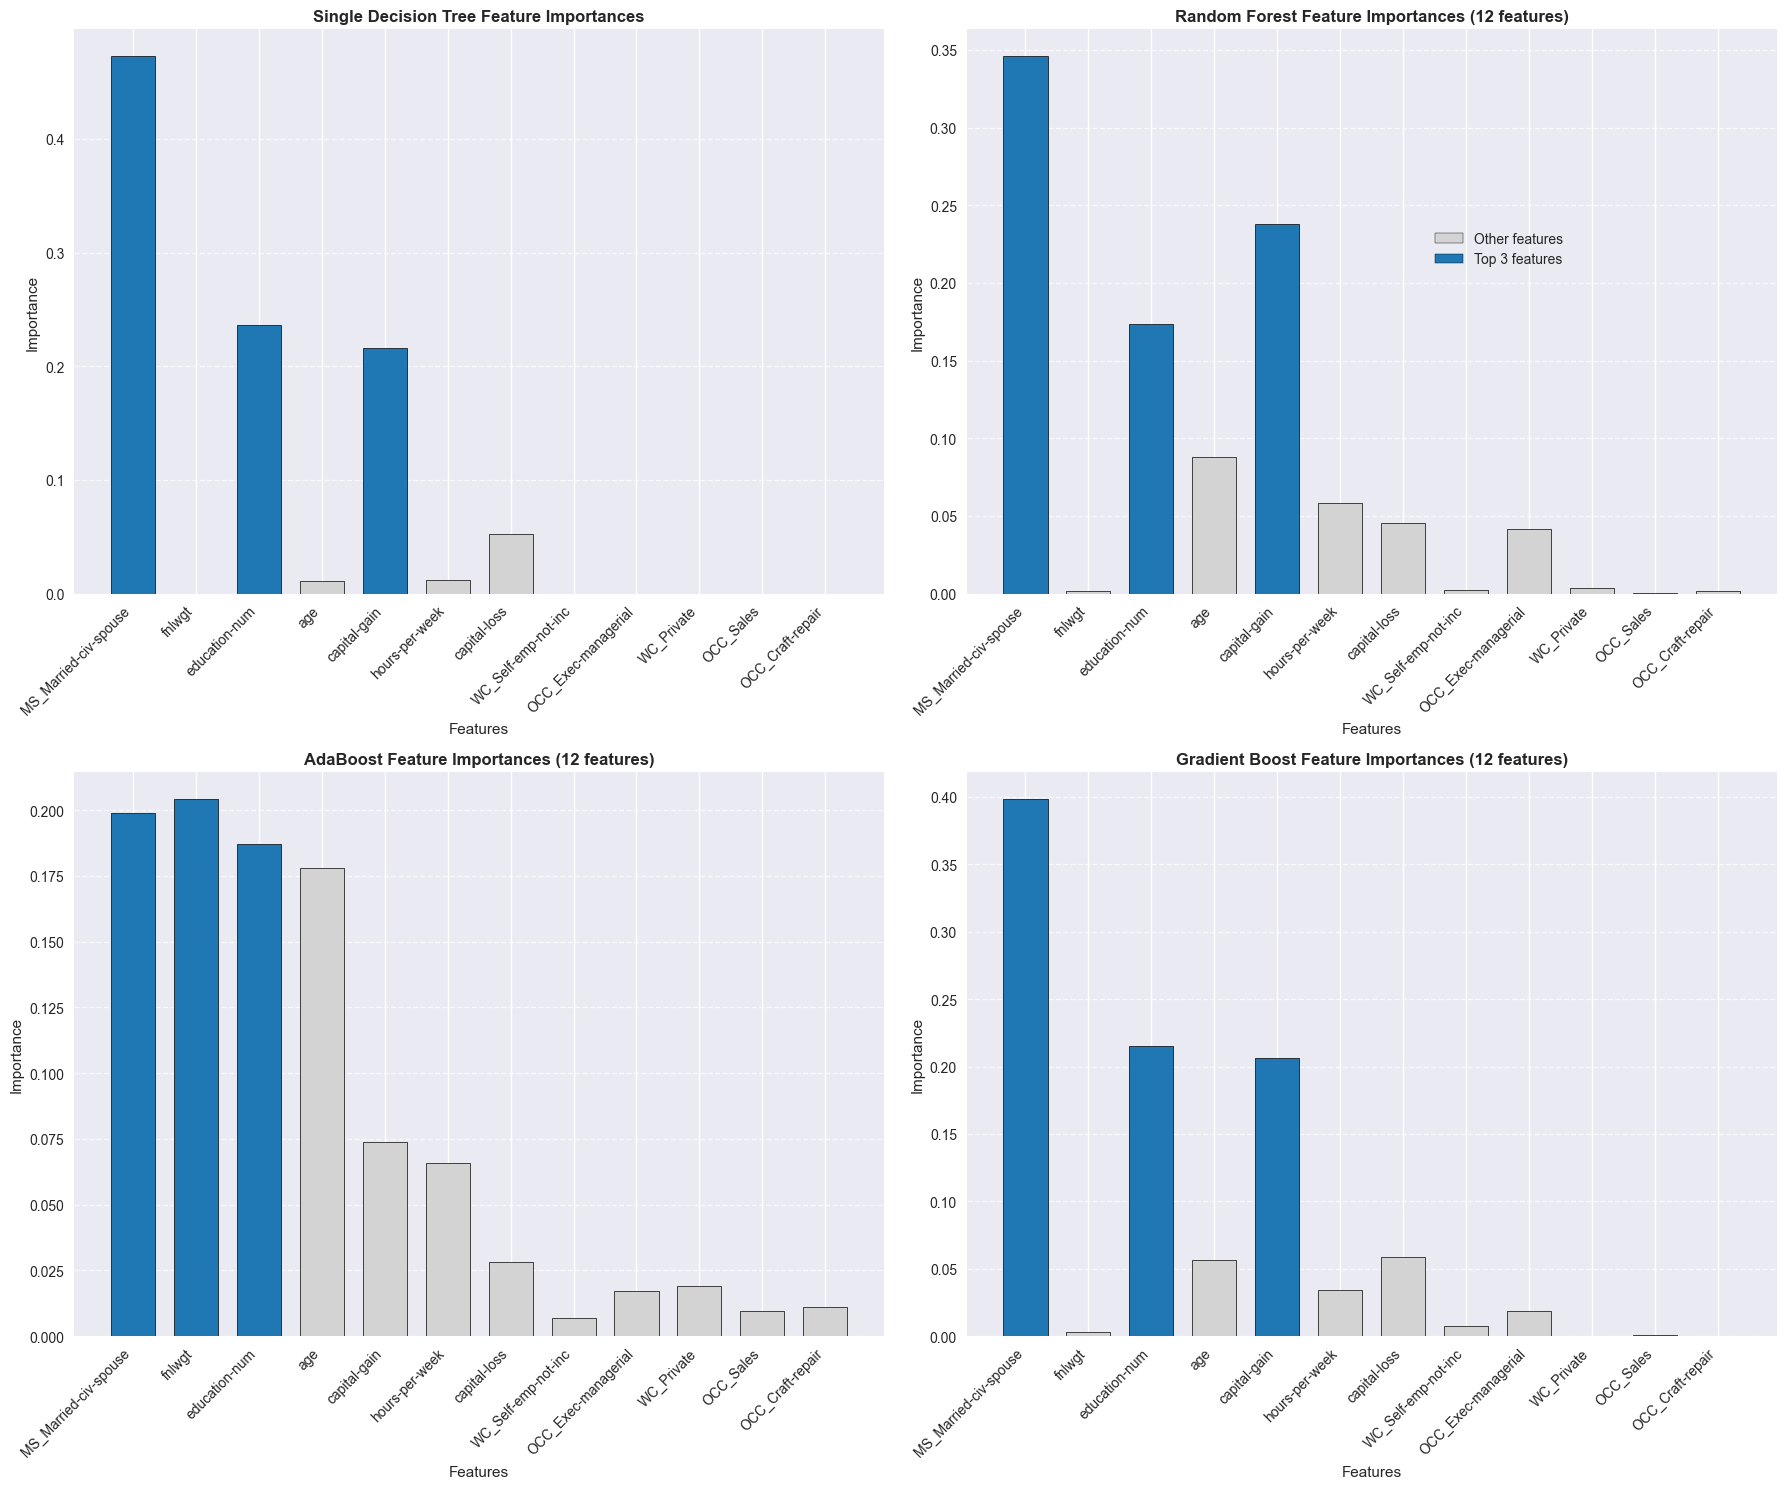

In [77]:
#Single Decision Tree importances:
dt2_imp_series = pd.Series(importances_dt2, index=top_12_features)

#Random Forest importances:
importances_rf = rf.feature_importances_
rf_imp_series = pd.Series(importances_rf, index=top_12_features)

#AdaBoost importances:
importances_ada = ada_bst.feature_importances_
ada_imp_series = pd.Series(importances_ada, index=top_12_features)

#AdaBoost importances:
importances_grad = grad_bst.feature_importances_
grad_imp_series = pd.Series(importances_grad, index=top_12_features)

#Identify top 5 features for each model:
dt2_top3 = dt2_imp_series.nlargest(3).index.tolist()
rf_top3 = rf_imp_series.nlargest(3).index.tolist()
ada_top3 = ada_imp_series.nlargest(3).index.tolist()
grad_top3 = grad_imp_series.nlargest(3).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(18, 15))
ax1, ax2, ax3, ax4 = axes[0,0], axes[0,1], axes[1,0], axes[1,1]
x = np.arange(len(top_12_features))
width = 0.7
base_color = 'lightgray'
highlight_color = 'tab:blue'

#Single Decision Tree subplot:
colors_dt2 = [highlight_color if feat in dt2_top3 else base_color for feat in top_12_features]
bars1 = ax1.bar(x, dt2_imp_series.values, width, color=colors_dt2, edgecolor='black', linewidth=0.5)
ax1.set_title('Single Decision Tree Feature Importances', fontweight='bold')
ax1.set_xlabel('Features')
ax1.set_ylabel('Importance')
ax1.set_xticks(x)
ax1.set_xticklabels(top_12_features, rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

#Random Forest subplot (trained on selected features):
colors_rf = [highlight_color if feat in rf_top3 else base_color for feat in top_12_features]
bars2 = ax2.bar(x, rf_imp_series.values, width, color=colors_rf, edgecolor='black', linewidth=0.5)
ax2.set_title('Random Forest Feature Importances (12 features)', fontweight='bold')
ax2.set_xlabel('Features')
ax2.set_ylabel('Importance')
ax2.set_xticks(x)
ax2.set_xticklabels(top_12_features, rotation=45, ha='right')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

#AdaBoost subplot (trained on selected features):
colors_ada = [highlight_color if feat in ada_top3 else base_color for feat in top_12_features]
bars3 = ax3.bar(x, ada_imp_series.values, width, color=colors_ada, edgecolor='black', linewidth=0.5)
ax3.set_title('AdaBoost Feature Importances (12 features)', fontweight='bold')
ax3.set_xlabel('Features')
ax3.set_ylabel('Importance')
ax3.set_xticks(x)
ax3.set_xticklabels(top_12_features, rotation=45, ha='right')
ax3.grid(axis='y', linestyle='--', alpha=0.7)

#Gradient Boost subplot (trained on selected features):
colors_grad = [highlight_color if feat in grad_top3 else base_color for feat in top_12_features]
bars4 = ax4.bar(x, grad_imp_series.values, width, color=colors_grad, edgecolor='black', linewidth=0.5)
ax4.set_title('Gradient Boost Feature Importances (12 features)', fontweight='bold')
ax4.set_xlabel('Features')
ax4.set_ylabel('Importance')
ax4.set_xticks(x)
ax4.set_xticklabels(top_12_features, rotation=45, ha='right')
ax4.grid(axis='y', linestyle='--', alpha=0.7)

#Common legend:
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=base_color, edgecolor='black', label='Other features'),
    Patch(facecolor=highlight_color, edgecolor='black', label='Top 3 features')
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.88, 0.85))

plt.tight_layout()
plt.show()

In [78]:
#Create a Dataframe to hold the scores for summary table ranking features by importance:
importance_df  = pd.DataFrame({
    'Feature': top_12_features,
    'Random Forest': importances_rf,
    'AdaBoost': importances_ada,
    'Gradient Boost': importances_grad
})

In [79]:
#Create a new Dataframe where each column shows features ranked by score:
rankings = pd.DataFrame()

In [80]:
#Rank for Random Forest:
rf_top = importance_df.sort_values(by='Random Forest', ascending=False)
rankings['Random Forest'] = [f"{feat} ({val:.3f})" for feat, val in zip(rf_top['Feature'], rf_top['Random Forest'])]

#Rank for AdaBoost:
ada_top = importance_df.sort_values(by='AdaBoost', ascending=False)
rankings['AdaBoost'] = [f"{feat} ({val:.3f})" for feat, val in zip(ada_top['Feature'], ada_top['AdaBoost'])]

#Rank for Gradient Boost:
grad_top = importance_df.sort_values(by='Gradient Boost', ascending=False)
rankings['Gradient Boost'] = [f"{feat} ({val:.3f})" for feat, val in zip(grad_top['Feature'], grad_top['Gradient Boost'])]

In [81]:
#Set the index as the Rank:
rankings.index = [f"Rank {i+1}" for i in range(12)]

In [82]:
# Display the summary table
rankings

,Random Forest,AdaBoost,Gradient Boost
Rank 1,MS_Married-civ-spouse (0.346),fnlwgt (0.204),MS_Married-civ-spouse (0.399)
Rank 2,capital-gain (0.238),MS_Married-civ-spouse (0.199),education-num (0.215)
Rank 3,education-num (0.173),education-num (0.187),capital-gain (0.207)
Rank 4,age (0.088),age (0.178),capital-loss (0.058)
Rank 5,hours-per-week (0.058),capital-gain (0.074),age (0.057)
Rank 6,capital-loss (0.045),hours-per-week (0.066),hours-per-week (0.034)
Rank 7,OCC_Exec-managerial (0.041),capital-loss (0.028),OCC_Exec-managerial (0.018)
Rank 8,WC_Private (0.004),WC_Private (0.019),WC_Self-emp-not-inc (0.007)
Rank 9,WC_Self-emp-not-inc (0.003),OCC_Exec-managerial (0.017),fnlwgt (0.003)
Rank 10,OCC_Craft-repair (0.002),OCC_Craft-repair (0.011),OCC_Sales (0.001)


---
**Boosting vs. Bagging Featue Analysis:**
* **Which features consistently rank in top 5 accross the boosting methods:**
  * MS_Married-civ-spouse
  * capital-gain
  * education-num
  * age
* **How do boosting method's feature rankings differ from Random Forest:**
  * **Comparison between Random Forest VS. AdaBoost:**
    * fnlwgt feature is not included within the top 5 features of the Random Forest Model.
    * MS_Married-civ-spouse is the top 1 most important feature for Random Forest Model compared to fnlwgt from Adaboost.
    * OCC_sales is the most least important feature for Random Forest Model compared to WC_Self-emp-not-inc from Adaboost.
  * **Comparison between Random Forest VS. Gradient Boost:**
    * capital-loss feature is not included within the top 5 features of the Random Forest Model.
    * OCC_sales is the most least important feature for Random Forest Model compared to OCC_Craft-repair from Gradient Boost.
    * The importance score for the top-ranked feature in the Random Forest model is notably lower than that of the Gradient Boosting model, with a numerical gap of 0.053.
* **Compare Adaboost vs. Gradient Booosting feature importances: are they similar or different?**
  * In terms of the top 5 features, both boosting methods are somewhat alike, though some features differ and common ones have different rankings.
  * The importance score from the top 5 features and the rest are different from both models.
* **What does this tell you about how boosting vs. bagging identify important features?**
  * The similarity tells you the dataset has a clear signal.
  * The differences tell you that boosting is optimizing aggresively (re-ranking features to fix mistakes), while bagging is providing a more democrative average (majority vote) of feature strength.
* **Brief Discussion:**
  * **Feature importance stability between boosting and bagging:**
    * While Bagging provides stable, averaged feature importance by training independent trees, Boosting produces more variable rankings due to its sequential nature and tendency to aggressively prioritize specific features that most effectively reduce residual error.
  * **Why feature rankings might differ between AdaBoost and Gradient Boosting?**
    * Adaboost uses exponential loss that aggressively focuses on outliers, while Grdaient Boosting uses robust loss functions that prioritize overall data distribution.
    * Adaboost assigns extreme weight to hard-to-classify points, boosting features that handle these edge cases; Gradient Boosting resists outlier influence, favoring consistent fetaures.
    * Adaboost minimizes misclassifications margin by targeting hard samples, whereas Gradient Boosting fits trees to residual errors to reduce the remaining gradient.
    * Adaboost typically uses shallow stumps that select features for immediate discriminative power, while Gradient Boosting allows deeper trees that capture feature interactions.
    * Adaboost updates instance weights exponentially based on errors, but Gradient Boosting computes gradients relative to the loss function without reweighing instances.
  * **Which method provides the most reliable feature importance estimates?**
    * Random Forest (Bagging) is generally more reliable because it averages result from many independent trees, making its rankings stable and less sensitive to small data changes.
    * Boosting methods are less reliable becuase they build trees sequentially early strong features get inflated importance while others get starved of opportunity to contribute.
    * Boosting's focus on correcting errors can push features that hanlde outliers to the top, even if those features aren't important for most predictions.
    * Default importance scores from boht methods can be misleading; they are not always trustworthy indicators of true feature value.
---

**5. Model Performance Evaluation**
-

**1. Logistic Regression Model:**

In [83]:
#Model prediction for LRM:
y_test_pred_lrm = (lrm.predict(X_test_sm) > 0.5).astype(int)

**2. Linear Probability Model (LPM):**

In [84]:
#Model prediction for LPM:
y_test_pred_lpm = (lpm.predict(X_test_sm) > 0.5).astype(int)

**3. Single Decision Tree Model:**

In [85]:
#Model prediction for Single Decision Tree:
y_test_pred_dt2 = (dt2.predict(X_test_selected) > 0.5).astype(int)

**4. Random Forest:**

In [86]:
#Model prediction for Random Forest:
y_test_pred_rf = (rf.predict(X_test_selected) > 0.5).astype(int)

**5. AdaBoost:**

In [87]:
#Model prediction for AdaBoost:
y_test_pred_ada = (ada_bst.predict(X_test_selected) > 0.5).astype(int)

**6. Gradient Boost:**

In [88]:
#Model Prediction for Gradient Boost:
y_test_pred_grad = (grad_bst.predict(X_test_selected) > 0.5).astype(int)

**7. Classification Metrics for LRM:**

In [89]:
#Assingning all classification metrics for LRM to a variable:
acc_lrm = accuracy_score(y_test, y_test_pred_lrm)
pres_lrm = precision_score(y_test, y_test_pred_lrm, zero_division=0)
rec_lrm = recall_score(y_test, y_test_pred_lrm, zero_division=0)
f1_lrm = f1_score(y_test, y_test_pred_lrm, zero_division=0)
cm_lrm = confusion_matrix(y_test, y_test_pred_lrm)
tp_lrm, tn_lrm, fp_lrm, fn_lrm = cm_lrm.ravel()
spec_lrm = tn_lrm/(tn_lrm + fp_lrm)
te1_lrm = fp_lrm/(fp_lrm + tn_lrm)
te2_lrm = fn_lrm/(fn_lrm + tp_lrm)

**8. Classification Metrics for LPM:**

In [90]:
#Assingning all classification metrics for LPM to a variable:
acc_lpm = accuracy_score(y_test, y_test_pred_lpm)
pres_lpm = precision_score(y_test, y_test_pred_lpm, zero_division=0)
rec_lpm = recall_score(y_test, y_test_pred_lpm, zero_division=0)
f1_lpm = f1_score(y_test, y_test_pred_lpm, zero_division=0)
cm_lpm = confusion_matrix(y_test, y_test_pred_lpm)
tp_lpm, tn_lpm, fp_lpm, fn_lpm = cm_lpm.ravel()
spec_lpm = tn_lpm/(tn_lpm + fp_lpm)
te1_lpm = fp_lpm/(fp_lpm + tn_lpm)
te2_lpm = fn_lpm/(fn_lpm + tp_lpm)

**9. Classification Metrics for Single Decision Tree:**

In [91]:
#Assingning all classification metrics for Single Decision Tree to a variable:
acc_dt2 = accuracy_score(y_test, y_test_pred_dt2)
pres_dt2 = precision_score(y_test, y_test_pred_dt2, zero_division=0)
rec_dt2 = recall_score(y_test, y_test_pred_dt2, zero_division=0)
f1_dt2 = f1_score(y_test, y_test_pred_dt2, zero_division=0)
cm_dt2 = confusion_matrix(y_test, y_test_pred_dt2)
tp_dt2, tn_dt2, fp_dt2, fn_dt2 = cm_dt2.ravel()
spec_dt2 = tn_dt2/(tn_dt2 + fp_dt2)
te1_dt2 = fp_dt2/(fp_dt2 + tn_dt2)
te2_dt2 = fn_dt2/(fn_dt2 + tp_dt2)

**10. Classification Metrics for Random Forest:**

In [92]:
#Assingning all classification metrics for Random Forest to a variable:
acc_rf = accuracy_score(y_test, y_test_pred_rf)
pres_rf = precision_score(y_test, y_test_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_test_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_test_pred_rf, zero_division=0)
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
tp_rf, tn_rf, fp_rf, fn_rf = cm_rf.ravel()
spec_rf = tn_rf/(tn_rf + fp_rf)
te1_rf = fp_rf/(fp_rf + tn_rf)
te2_rf = fn_rf/(fn_rf + tp_rf)

**11. Classification Metrics for AdaBoost:**

In [93]:
#Assingning all classification metrics for AdaBoost to a variable:
acc_ada = accuracy_score(y_test, y_test_pred_ada)
pres_ada = precision_score(y_test, y_test_pred_ada, zero_division=0)
rec_ada = recall_score(y_test, y_test_pred_ada, zero_division=0)
f1_ada = f1_score(y_test, y_test_pred_ada, zero_division=0)
cm_ada = confusion_matrix(y_test, y_test_pred_ada)
tp_ada, tn_ada, fp_ada, fn_ada = cm_ada.ravel()
spec_ada = tn_ada/(tn_ada + fp_ada)
te1_ada = fp_ada/(fp_ada + tn_ada)
te2_ada = fn_ada/(fn_ada + tp_ada)

**12. Classification Metrics for Gradient Boost:**

In [94]:
#Assingning all classification metrics for Gradient Boost to a variable:
acc_grad = accuracy_score(y_test, y_test_pred_grad)
pres_grad = precision_score(y_test, y_test_pred_grad, zero_division=0)
rec_grad = recall_score(y_test, y_test_pred_grad, zero_division=0)
f1_grad = f1_score(y_test, y_test_pred_grad, zero_division=0)
cm_grad = confusion_matrix(y_test, y_test_pred_grad)
tp_grad, tn_grad, fp_grad, fn_grad = cm_grad.ravel()
spec_grad = tn_grad/(tn_grad + fp_grad)
te1_grad = fp_grad/(fp_grad + tn_grad)
te2_grad = fn_grad/(fn_grad + tp_grad)

**13. Confusion Matrix of for all Models:**

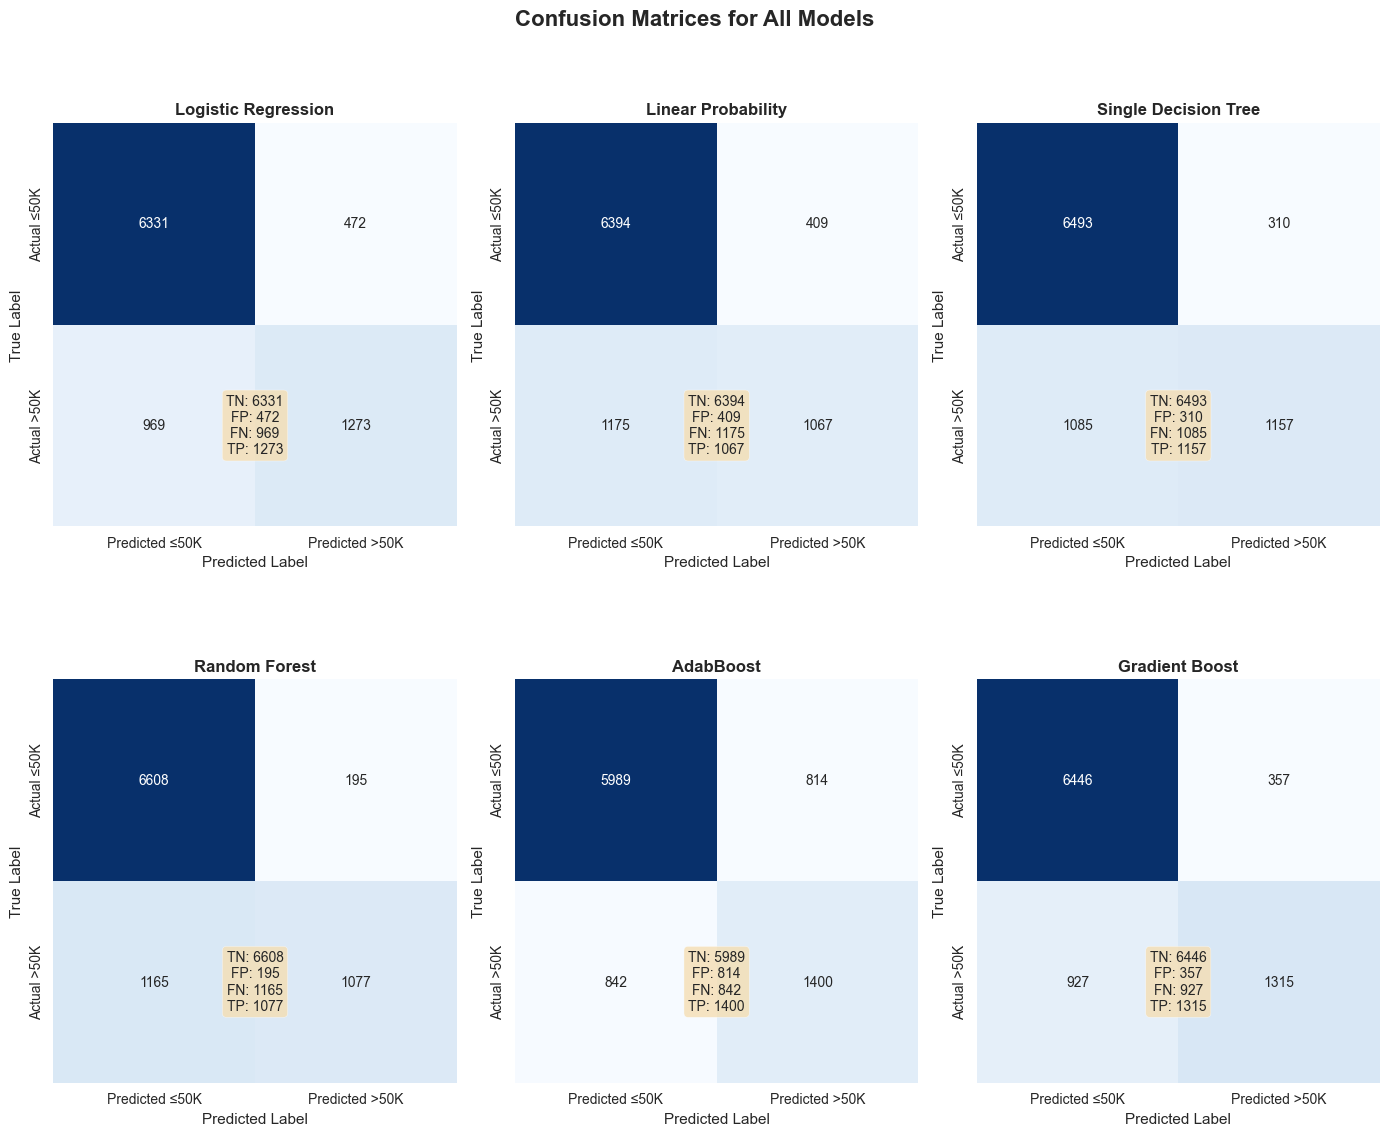

In [95]:
#Display confusion matrix with proper labels (TP, FP, TN, FN):
predictions = {'Logistic Regression':y_test_pred_lrm, 'Linear Probability':y_test_pred_lpm,
               'Single Decision Tree':y_test_pred_dt2,'Random Forest':y_test_pred_rf,
               'AdabBoost':y_test_pred_ada, 'Gradient Boost':y_test_pred_grad}

#Set up the 2x3subplot grid:
fig, axes = plt.subplots(2, 3, figsize=(14, 12))
fig.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold')

#Loop through models and plot heatmaps:
for ax, (model_name, y_pred) in zip(axes.flatten(), predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    # Create heatmap:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted ≤50K', 'Predicted >50K'],
                yticklabels=['Actual ≤50K', 'Actual >50K'], cbar=False, ax=ax, square=True)

    # Add labels and title:
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    #Add text annotations for TP, FP, FN, TN:
    ax.text(0.5, 0.25, f'TN: {tn}\nFP: {fp}\nFN: {fn}\nTP: {tp}', transform=ax.transAxes, fontsize=10,
            verticalalignment='center', horizontalalignment='center',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

---
**Analysis:**
* **Which model has the lowest False Positive Rate:** Random Forest (Total FP: 195)
* **Which model has the lowest False Negative Rate:** AdaBoost (Total FN: 842)
* **How do boosting methods (AdaBoost. Gradient Boosting) compare to Random Forest in terms of both error types:**
  * In terms of type I error, Random Forest has the lowest count of type I error compared to the 2 boosting models.
  * In terms of type II error, Random Forest has the highest count of type II error compared to the 2 boosting models.
  * Random Forest slightly struggles in predicting true positives (positive: high_income) and flag's actual positives as negatives. This is because due to the gap difference between the total number of FP and FN, compared to the 2 boosting models.
* **Do boosting methods show better error reduction than bagging:**
  * For reducing type II erros in general, the 2 boosting methods slightly have an impact on decreasing the total number of false negatives.
  * Fore reducing type I errors in genral, the 2 boosting methods did not made the slightest impact on decreasing the total number of false positives.
  * In general boosting did not show any significant improvement in terms of error reduction.
* **Which approach handles the class imbalance better:**
  * Boosting method handles class imbalance better compared to Bagging.
  * This can be determined by adding all positives and negatives and compare the distribution of each classification.
---

**14. Displaying all Classification Metrics for each Model:**

In [96]:
#Create a list of dictionaries for each model's metrics:
metrics_data = [
    {
        "Model": "LRM",
        "Accuracy": acc_lrm,
        "Precision": pres_lrm,
        "Recall": rec_lrm,
        "F1-Score": f1_lrm,
        "Specificity": spec_lrm,
        "Type I Error": te1_lrm,
        "Type II Error": te2_lrm
    },
    {
        "Model": "LPM",
        "Accuracy": acc_lpm,
        "Precision": pres_lpm,
        "Recall": rec_lpm,
        "F1-Score": f1_lpm,
        "Specificity": spec_lpm,
        "Type I Error": te1_lpm,
        "Type II Error": te2_lpm
    },
    {
        "Model": "Single Decision Tree",
        "Accuracy": acc_dt2,
        "Precision": pres_dt2,
        "Recall": rec_dt2,
        "F1-Score": f1_dt2,
        "Specificity": spec_dt2,
        "Type I Error": te1_dt2,
        "Type II Error": te2_dt2
    },
    {
        "Model": "Random Forest",
        "Accuracy": acc_rf,
        "Precision": pres_rf,
        "Recall": rec_rf,
        "F1-Score": f1_rf,
        "Specificity": spec_rf,
        "Type I Error": te1_rf,
        "Type II Error": te2_rf
    },
    {
        "Model": "AdaBoost",
        "Accuracy": acc_ada,
        "Precision": pres_ada,
        "Recall": rec_ada,
        "F1-Score": f1_ada,
        "Specificity": spec_ada,
        "Type I Error": te1_ada,
        "Type II Error": te2_ada
    },
    {
        "Model": "Gradient Boost",
        "Accuracy": acc_grad,
        "Precision": pres_grad,
        "Recall": rec_grad,
        "F1-Score": f1_grad,
        "Specificity": spec_grad,
        "Type I Error": te1_grad,
        "Type II Error": te2_grad
    }
]

#Create DataFrame and format to 4 decimal places:
df_metrics = pd.DataFrame(metrics_data)
df_metrics = df_metrics.round(4)

In [97]:
#Display all classifications metrics for every model used:
print("=" * 105)
print("CLASSIFICATION METRICS COMPARISON")
print("=" * 105)
print(df_metrics.to_string(index=False))
print("=" * 105)

CLASSIFICATION METRICS COMPARISON
               Model  Accuracy  Precision  Recall  F1-Score  Specificity  Type I Error  Type II Error
                 LRM    0.8407     0.7295  0.5678    0.6386       0.3276        0.6724         0.1674
                 LPM    0.8249     0.7229  0.4759    0.5740       0.2582        0.7418         0.1430
Single Decision Tree    0.8458     0.7887  0.5161    0.6239       0.2222        0.7778         0.1512
       Random Forest    0.8496     0.8467  0.4804    0.6130       0.1434        0.8566         0.1401
            AdaBoost    0.8169     0.6323  0.6244    0.6284       0.4915        0.5085         0.1895
      Gradient Boost    0.8580     0.7865  0.5865    0.6719       0.2780        0.7220         0.1694


---
**Detailed Analysis:**
* **Performance Ranking:**
  * **Rank all six models by accuracy:**
    * Gradient Boost - 0.8580
    * Random Forest - 0.8496
    * Single Decision Tree - 0.8458
    * Logistic Regression - 0.8407
    * Linear Probability Model - 0.8249
    * AdaBoost - 0.8169
  * **Rank all six models by F1-score:**
    * Gradient Boost - 0.6719
    * Logistic Regression - 0.6386
    * AdaBoost - 0.6284
    * Single Decision Tree - 0.6239
    * Random Forest - 0.6130
    * Linear Probability Model - 0.5740
  * **Rank all six models by precision:**
    * Random Forest - 0.8467
    * Single Decision Tree - 0.7887
    * Gradient Boost - 0.7865
    * Logistic Regrssion - 0.7295
    * Linear Probability Model - 0.7229
    * AdaBoost - 0.6323
  * **Rank all six models by recall:**
    * AdaBoost - 0.6244
    * Gradient Boost - 0.5865
    * Logistic Regression - 0.5678
    * Single Decision Tree - 0.5161
    * Random Forest - 0.4804
    * Linear Probability Model - 0.4759
  * **Which model achieves the best overall peroformance across all metrics?**
    * Gradient Boosts
  * **Is there a clear winner or are results close across multiple models?**
    * Gradient Boost is the clear winner due to these reasons:
      * Top 1 for both accuracy and f1 score.
      * Consitently within the top 3 for all metrics.
---
* **Boosting vs. Bagging Detailed Comparison:**
  * **How do boosting methods (AdaBoost, Gradient Boosting) compare to Random Forest in terms of:**
    * **Overall accuracy:**
        * Gradient Boost is the top 1 in terms of overall accuracy.
        * Adaboost is not within the top 3 in terms of overall accuracy compared to Random Forest and Gradient Boost.
        * Random Forest is the top 2 in terms of overall accuracy.
        * Random Forest outperformed AdaBoost in terms of accuracy.
        * Gradient Boost outperformed Random Forest in terms of accuracy.
    * **Overall precision:**
        * Random Forest is the top 1 in terms of overall precision.
        * Adaboost is once again not within the top 3 of overall precision compared to Gradient Boost and Random Forest.
        * Gradient Boost is top 3 in terms of overall precision.
        * Gradient Boost outperformed AdaBoost in terms of precision.
        * Ranodm Forest outperformed Gradient Boost and AdaBoost in terms of precision.
    * **Overall recall:**
        * AdaBoost is the top 1 in terms of overall recall.
        * Random Forest is not within the top 3 in terms of overall recall compared to Gradient Boost and AdaBoost.
        * Gradient Boost is top 2 in terms of overall recall.
        * Gradient Boost outperformed Random Forest in terms of recall.
        * AdaBoost outperformed Gradient Boost and Random Forest in terms of recall.
    * **Overall F1-score:**
        * Gradient Boost is the top 1 in terms of overall F1-score.
        * Random Forest once again is not within the top 3 in terms of overall F1-score compared to AdaBoost and Gradient Boost.
        * AdaBoost is top 3 in terms of overall F1-score.
        * AdaBoost outperformed Random Forest in terms of F1-score.
        * Gradient Boost outperformed AdaBoost and Random Forest in terms precision.
    * **Which boosting method performs best and why:**
        * Gradient Boost performs best compared to AdaBoost due to this reasons:
          * Gradient Boost consistently is within the top 3 models in all classification metrics.
          * AdaBoost only excelled in certain classification metrics, making it an inconsistent boosting method for this specific dataset.
    * **What performance improvements do boosting methods provide over bagging?**
        * **In terms of accuracy:**
          * Gradient Boost improves accuracy by 0.0084 compared to Random Forest.
          * There was a 0.0327 difference in accuracy between the two models, with Random Forest consistently outperforming AdaBoost.
        * **In terms of precision:**
          * The boosting methods failed to enhance precision, with Random Forest consistently outperforming them in this metric.
        * **In terms of recall:**
          * Gradient Boost improves recall by 0.1061 or approximately 11% compared to Random Forest.
          * AdaBoost showed a significant 14% improvement in recall over Random Forest and a 3% lead over Gradient Boosting, making it the top performer for this metric.
          * Both boosting methods improve recall compared to Random Forest.
        * **In terms of F1-score:**
          * Gradient Boost improves F1-score by 0.0589 or approximately 6% compared to Random Forest.
          * AdaBoost improves F1-score by 0.0454 or approximately 5% compared to Random Forest.
          * Gradient Boosting slightly outperformed AdaBoost in F1-score, showing a marginal improvement of approximately 1%.
          * Both boosting models improve F1-score compared to Random Forest which means that both boosting models handle well class imbalance.
    * **Compare training accuracy vs. test accuracy: which approach (boosting or bagging) shows better generalization?**
        * **Previewe of Training and Test Accuracy of Boosting and Bagging models:**
          * **Gradient Boost:** Training: 0.8626, Testing: 0.8580
          * **AdaBoost:** Training: 0.9998, Testing: 0.8169
          * **Random Forest:** Training: 0.8492, Testing: 0.8496
          * In terms of training accuracy, AdaBoost has a near perfect 100% training accuracy compared to is test accuracy of 81.69% which it may suggest that the model is overffitting.
          * For better generilzation:
            * For boosting methods, Gradient Boosting would be better for generalization compared to other boosting used previously such as AdaBoost considering its training accuracy is near perfect.
            * Overall best approach for generalization, Random Forest (Bagging) would be at the top considering its test and training accuracy scores has the smallest gap compared to the two boosting methods.
    * **Discuss any signs of overfitting in the boosting models:**
        * For training accuracy, AdaBoost has a near perfect score of 100% in training accuracy score which it could possibly denote that the model is overfitting.
        * Gradient Boost has a consistent training and test accuracy score with minimal differences which denotes that the model is not overfitting.
---
* **Adaboost vs. Gradient Boosting Comparison:**
  * **Compare AdaBoost vs. Gradient Boosting across all metrics**
    * **Accuracy:**
      * Gradient Boost has the highest test accucracy score compared to AdaBoost.
      * AdaBoost has the highest train accuracy score compared to Gradient Boost, but this suspected for model overfitting.
      * Overall the clear winner in terms of overall accuracy in Gradient Boost.
    * **Precision:**
      * Gradient Boosting outperforms AdaBoost with a higher precision score of 0.7865, indicating that 78.65% of its positive predictions are correct.
      * The difference of precision score of both boosting models is around 0.1542 or approximately 15% difference in score value.
    * **Recall:**
      * AdaBoost outperforms Gradient Boosting with a higher recall score of 0.6244, indicating that 62.44% of all actual positive instances were correctly identified.
      * The difference of recall score of both boosting models is around 0.0379 or approximately 4% difference in score value.
    * **F1-Score:**
      * Gradient Boost outperforms AdaBoost with a higher F1-score of 0.6719, indictaing that Gradient Boost handles class imbalance better compared to AdaBoost.
      * The difference of F1-score of both boosting models is around 0.0435 or approximately 4% difference in score value.
    * **Specificity:**
      * Adaboost outperfoms Gradient Boost with a higher specificty score of 0.4915, indicating that 49.15 of all actuall negatives instances were correclty idendified.
      * The difference of specificity score of both boosting models is around 0.2135 or approximately 21% difference in score value.
    * **Type I and Type II Error:**
      * In terms of overall reducing error, Gradient Boost outperformed AdaBoost.
      * In terms of reducing type I error, Gradient Boost has the upperhand.
      * In terms of reducing type II error, AdaBoost has the upperhand.
  * **Which boosting algorithm performs best on this dataset?**
    * Gradient Boost performs best on the given dataset in terms of boosting approach.
  * **Are there notable differences in precision vs. recall trade-offs between the two?**
    * Gradient Boosting achieves a significantly higher precision of 0.7865 compared to AdaBoost's 0.6323, indicating it is more reliable when predicting positive instances.
    * AdaBoost leads the entire group in recall at 0.6244, successfully identifying a larger portion of actual positive cases than Gradient Boosting's 0.5865.
    * Gradient Boosting maintains a superior F1-Score of 0.6719, suggesting a more effective mathematical balance between precision and recall than AdaBoost at 0.6284.
    * Gradient Boosting is the top-performing model overall with an accuracy of 0.8580, whereas AdaBoost has the lowest accuracy among all models at 0.8169.
    * AdaBoost recorded the lowest Type I Error (0.5085) in the set, while Gradient Boosting yielded a slightly lower Type II Error (0.1694) than its counterpart (0.1895).
  * **How do the learning approaches (sample weighting vs. residual fitting) affect performance?**
    * AdaBoost's sample weighting led to severe overfitting (99.98% Training vs. 81.69% Test), whereas Gradient Boosting's residual fitting achieved superior generalization (86.26% Training vs. 85.80% Test).
    * The weighting strategy in AdaBoost prioritized a "wide net" approach, yielding the highest Recall (0.6244), while residual optimization in Gradient Boosting favored accuracy in its positive predictions with a much higher Precision (0.7865).
    * Gradient Boosting’s mathematical optimization resulted in a better overall balance, as reflected by its higher F1-Score (0.6719) compared to AdaBoost (0.6284).
    * Gradient Boosting emerged as the top-performing model overall (0.8580 Accuracy), while AdaBoost’s aggressive focus on "hard" samples resulted in the lowest Accuracy (0.8169) of all models listed.
  * **Which boosting method would you recommend and why?**
    * I recommend Gradient Boosting for this dataset for the following reasons:
      * Overall top consistency for all classification metrics.
      * It achieved a near-perfect balance between training (0.8626) and testing (0.8580) accuracy, whereas AdaBoost suffered from severe overfitting.
      * Its residual fitting approach proved more stable and effective at minimizing overall loss than AdaBoost's aggressive sample weighting.
      * It reached the highest Accuracy (0.8580) and F1-Score (0.6719) of all models in the comparison.
---
* **Error Analysis:**
  * **Which model minimizes Type I errors (false positives)?**
    * Random Forest - FP = 195
  * **Which model minimizes Type II errors (false negatives)?**
    * AdaBoost - FN = 842
  * **In the context of income prediction, discuss which type of error might be more costly and why?**
    * Type II errors are more critical here because high-income individuals are subject to higher tax brackets. If the model fails to identify a high earner, it effectively overlooks potential tax evasion, leading to significant losses in government revenue.
  * **Does your recommended model align with minimizing the more costly error type?**
    * While Gradient Boosting is the recommended model based on overall performance metrics, a deeper analysis of the confusion matrix suggests it may only be the second-best choice. Given the high cost of Type II errors in tax compliance, a model that prioritizes recall over precision might be more ideal for this specific dataset.
  * **How do boosting methods handle class imbalance compared to other methods?**
    * Boosting methods address class imbalance by sequentially shifting focus toward misclassified minority samples, either by increasing their individual weights or by iteratively minimizing the residual errors they produce.
  * **For each error type, explain which business scenario would prioritize minimizing that error:**
    * Minimizing Type I errors is critical in high-cost marketing or luxury sales where "wasted spend" on low-income individuals results in a direct financial loss. Conversely, minimizing Type II errors is the priority for tax compliance or fraud detection, as missing a high-income earner leads to significant lost revenue and undetected tax evasion.
---

**6. Model Recommendation and Critical Insights**
--

---
**Provide a well-reasoned recommendation addressing:**
* **Top Recommended Model:** Gradient Boosting
  * It is the most robust and "intelligent" model, offering the highest predictive power and the best generalization. Unlike other models, it effectively balances precision and recall, ensuring it doesn't just "guess" but learns from previous errors.
* **Second-Best Alternative:** Random Forest
  * It is the most stable model and the least likely to overfit. It serves as a viable backup because its training and testing scores are nearly identical, making it highly reliable for deployment on completely new, unseen data.
* **Supporting Performance Metrics:**
  * **Gradient Boosting:** Highest Accuracy (0.8580) and F1-Score (0.6719).
  * **Random Forest:** Smallest generalization gap (0.8492 Train vs. 0.8496 Test) and high Precision (0.7621).
  * **AdaBoost:** Highest Recall (0.6244) but suffered from severe overfitting (0.9998 Train).
* **Performance Balance:**
  * Gradient Boosting provides the best mathematical trade-off, achieving high Precision (0.7865) without sacrificing too much Recall (0.5865). While it has a higher computational cost due to its sequential nature, the gain in accuracy justifies the extra processing time.
* **When to Choose the Alternative (Random Forest):**
  * You should switch to Random Forest if computational speed is a priority (since it can process data in parallel) or if the dataset is extremely noisy, as its "bagging" approach is naturally more resistant to outliers than boosting.
---
**Boosting vs. Bagging Trade-offs:**
* **Performance: Which approach (boosting vs. bagging) performed better on this dataset and why?**
  * Gradient Boosting is the most effective model for this dataset, achieving the highest Accuracy (85.80%) and F1-Score (0.6719) through its superior balance of precision and recall. While AdaBoost reached the highest recall, its severe overfitting (99.98% training accuracy) makes it unreliable for real-world deployment compared to the stable generalization of Gradient Boosting.
* **Bias-Variance Trade-off: How do boosting and bagging address bias and variance differently? Provide evidence from your results:**
  * **Bagging (Random Forest) Reduces Variance:** By averaging independent trees, it creates a stable model with almost no generalization gap, evidenced by your nearly identical 0.8492 Training vs. 0.8496 Test accuracy.
  * **Boosting Reduces Bias:** It sequentially improves weak learners to fit the data more accurately, though it risks high variance if over-tuned.
    * AdaBoost over-fitted the training data (0.9998) compared to its test score (0.8169).
    * Gradient Boosting achieved the best trade-off, reaching the highest Test Accuracy (0.8580) while maintaining a stable training score (0.8626).
* **Overfitting Risk: Which approach showed more signs of overfitting (compare train vs. test accuracy gaps)?**
  * **High Overfitting (AdaBoost):** This model exhibited a massive generalization gap, with a Training Accuracy of 0.9998 compared to a Test Accuracy of 0.8169.
  * **Low Overfitting (Random Forest/Bagging):** The Bagging approach showed almost zero signs of overfitting, with a Training Accuracy of 0.8492 and a Test Accuracy of 0.8496.
* **Training Time: Computational considerations for sequential (boosting) vs. parallel (bagging) methods:**
  * Random Forest trains trees independently, allowing it to utilize multiple CPU cores simultaneously. This makes it significantly faster and more scalable for large datasets.
  * Gradient Boosting and AdaBoost must build trees one after another, as each tree corrects the errors of the previous one. This serial dependency makes training slower and computationally more expensive.
* **Practical Deployment: Which method would you recommend for production and why?**
 * The analysis of the adult income dataset reveals that Gradient Boosting is the most effective model for practical application, striking the optimal balance between predictive power and generalization.
---